# Analitika financija - Prva laboratorijska vježba

---


<b>Uvod i upute za predaju</b>

Prva laboratorijska vježba iz Analitike financija sastoji se od pet zadataka koje je potrebno riješiti u programskom jeziku Python, rješavajući zadatke unutar Juypyter bilježnice. 

Rješavanje vježbe svodi se na čitanje uputa u ćelijama s tekstom, nadopunjavanje blokova kôda (možete dodavati i dodatne blokove kôda ukoliko je potrebno) i ispisivanje rezultata (u vidu ispisa iz funkcija, tablica i grafova). Pritom morate razumjeti teorijske osnove implementiranih rješenja, u okviru onoga što je obrađeno na predavanjima.

Zadatci u samoj vježbi su istraživačkog tipa - ne postoji nužno samo jedan točan način rješavanja svakog zadatka, zato potičemo studente na eksperimentiranje. 

Osim ako u određenom zadatku ne piše drugačije, za implementaciju rješenja možete koristiti proizvoljne biblioteke.

Vaše rješenje (bilježnicu) potrebno je poslati na e-mail adresu `tomislav.kovacevic@fer.hr` u formatu naziva `IME_PREZIME_JMBAG.ipynb`. Na istu e-mail adresu možete se javiti s bilo kakvim pitanjima vezanim uz ovu vježbu.

Na ovoj vježbi možete ostvariti ukupno 20 bodova. Vaša Jupyter bilježnica ocjenjivat će se s mogućnošću ostvarivanja do 5 bodova, a na usmenoj obrani moguće je ostvariti preostalih 15 bodova.
U svom radu smijete koristiti sve alate na raspolaganju (uključujući i alate umjetne inteligencije), ali će se prilikom usmene obrane strogo provjeravati razumijete li sve detalje svog rješenja - ukoliko ne razumijete neki dio vlastitog koda, smatrat će se da taj zadatak niste riješili. Osim toga, provjeravat će se i originalnost rješenja - predstavljanje tuđeg rada kao vlastitog je kršenje kodeksa ponašanja studenata i takvi slučajevi bit će prijavljeni povjerenstvu za stegovnu odgovornost.

Vježbu radite samostalno, a svoje rješenje branite na terminima koji su vam dodijeljeni u kalendaru. Podsjećamo da bodovi iz laboratorijskih vježbi ulaze i u bodove na ispitnom roku, te da je za polaganje predmeta potrebno imati barem 30\% ukupnih bodova iz laboratorijskih vježbi. Nadoknade laboratorijskih vježbi neće biti organizirane.


## Zadatak 1 - Povezanost BDP-a, inflacije i kamatnih stopa 

Tri .csv datoteke, smještene u mapi data/zadatak_1, sadrže kvartalne povijesne podatke za:

1. Nominalni BDP (GDP.csv)
2. Realni BDP (GDPC1.csv)
3. Kamatne stope (IR.csv)

Svaka datoteka uključuje dva stupca:

Datum: Kvartalno razdoblje,
Vrijednost: Zabilježeni podatak (BDP ili kamatna stopa) za taj kvartal.

In [2]:
import pandas as pd

# Učitavanje podataka za Nominalni BDP, Realni BDP i Kamatne stope
gdp_df = pd.read_csv('data/zadatak_1/GDP.csv')
real_gdp_df = pd.read_csv('data/zadatak_1/GDPC1.csv')
ir_df = pd.read_csv('data/zadatak_1/IR.csv')

# Pregled svake datoteke kako bismo razumjeli strukturu podataka
gdp_df.head(), real_gdp_df.head(), ir_df.head()

(         DATE      GDP
 0  1947-01-01  243.164
 1  1947-04-01  245.968
 2  1947-07-01  249.585
 3  1947-10-01  259.745
 4  1948-01-01  265.742,
          DATE     GDPC1
 0  1947-01-01  2182.681
 1  1947-04-01  2176.892
 2  1947-07-01  2172.432
 3  1947-10-01  2206.452
 4  1948-01-01  2239.682,
          DATE  IR3TIB01USM156N
 0  1964-06-01             3.86
 1  1964-07-01             3.87
 2  1964-08-01             3.85
 3  1964-09-01             3.87
 4  1964-10-01             3.94)

Pretvorite kvartalne podatke u godišnje prosjeke.

In [3]:
def calculate_average_per_year(df, value):
   df['Year'] = df['DATE'].str[:4]
   average_per_year = df.groupby('Year')[value].mean().reset_index()
   return average_per_year

avg_nominal_gdp = calculate_average_per_year(gdp_df, 'GDP')
avg_real_gdp = calculate_average_per_year(real_gdp_df, 'GDPC1')
avg_interest_rate = calculate_average_per_year(ir_df, 'IR3TIB01USM156N')
avg_nominal_gdp.tail(), avg_real_gdp.head(), avg_interest_rate.head()

(    Year          GDP
 73  2020  21354.10475
 74  2021  23681.17075
 75  2022  26006.89250
 76  2023  27720.70950
 77  2024  28820.39150,
    Year       GDPC1
 0  1947  2184.61425
 1  1948  2274.62650
 2  1949  2261.92775
 3  1950  2458.53175
 4  1951  2656.32000,
    Year  IR3TIB01USM156N
 0  1964         3.931429
 1  1965         4.344167
 2  1966         5.483333
 3  1967         5.020833
 4  1968         5.859167)

Vizualizirajte godišnje prosjeke učitanih podataka i njihove promjene između godina.

<Figure size 1600x800 with 0 Axes>

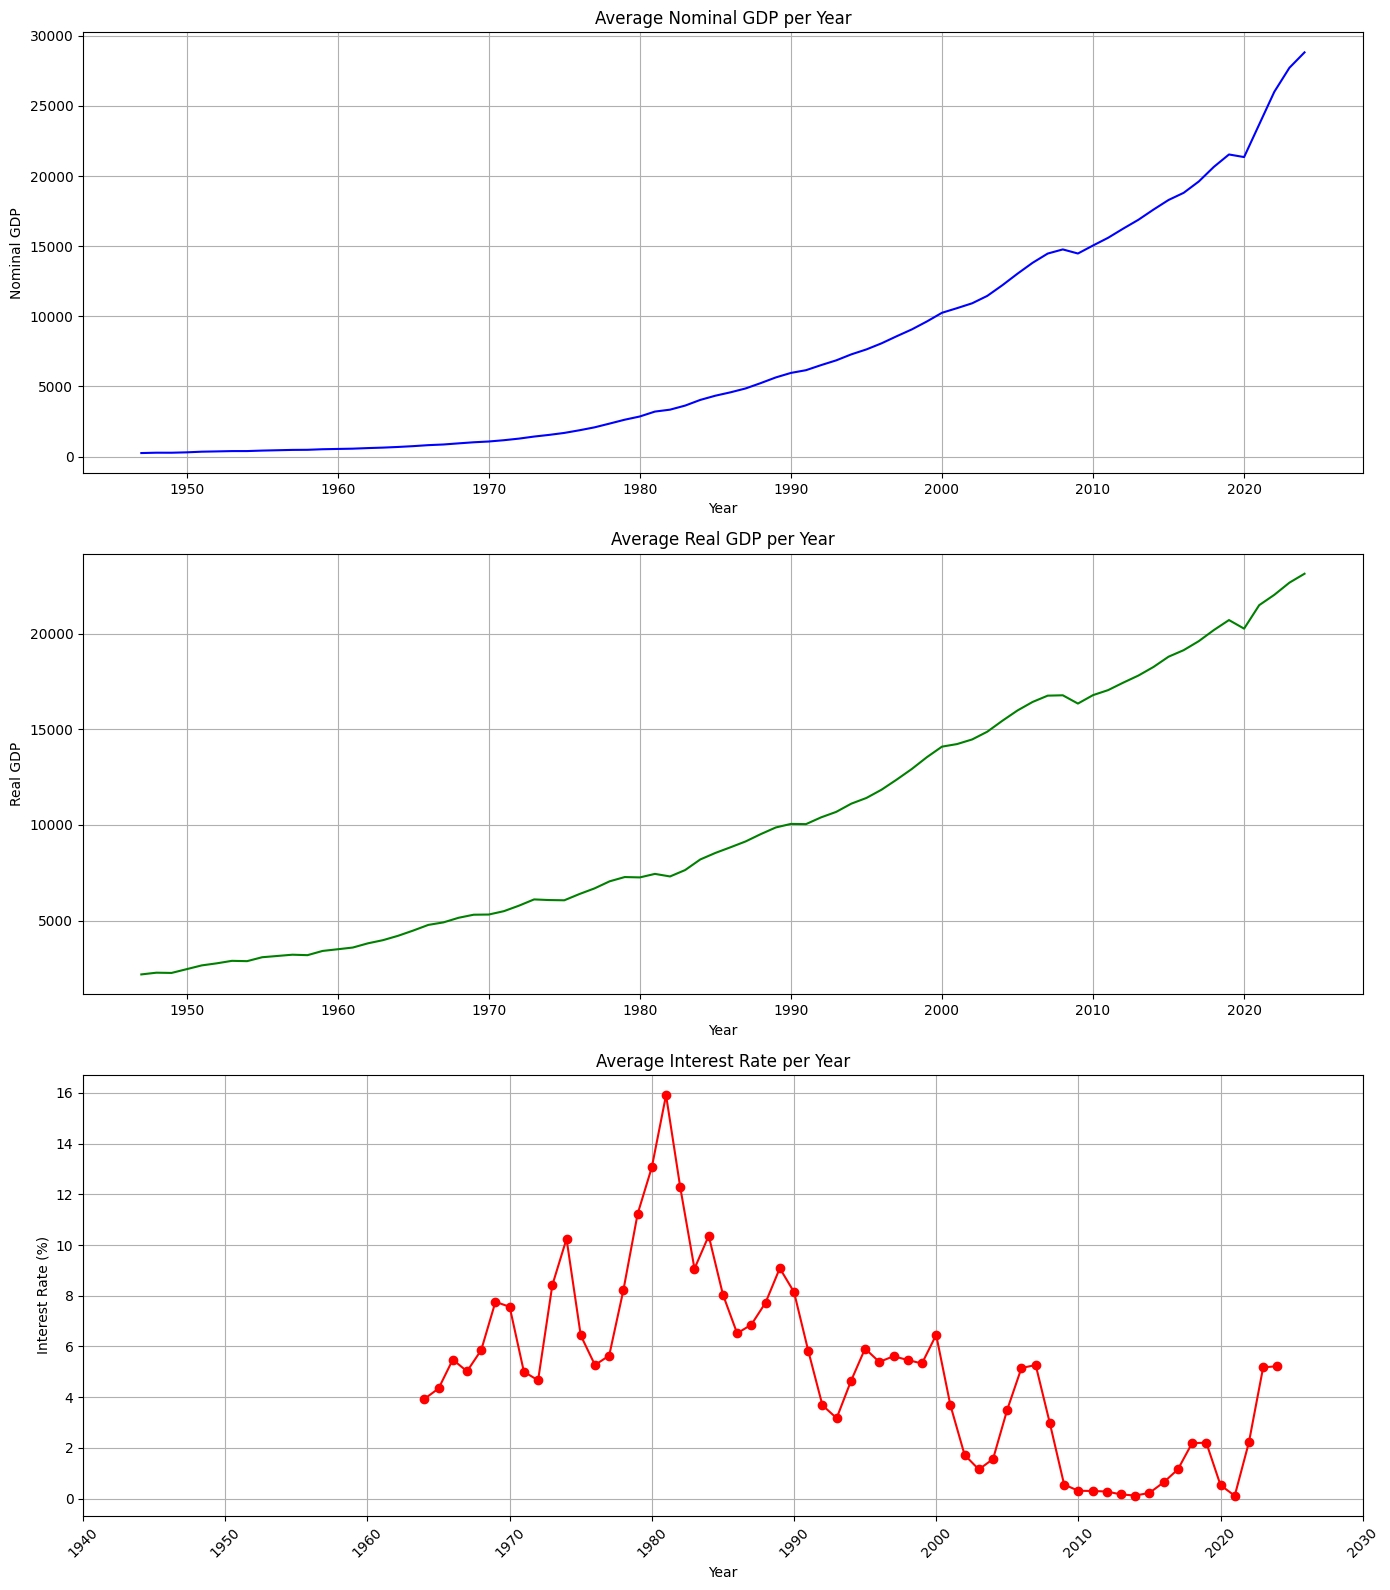

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 8))

avg_nominal_gdp['Year'] = pd.to_numeric(avg_nominal_gdp['Year'])
avg_real_gdp['Year'] = pd.to_numeric(avg_real_gdp['Year'])
avg_interest_rate['Year'] = pd.to_numeric(avg_interest_rate['Year'])

start_year = int(avg_nominal_gdp['Year'].min())
end_year = int(avg_nominal_gdp['Year'].max())
ticks = np.arange(start_year - (start_year % 10), end_year + 10, 10)

fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=False)

axes[0].plot(avg_nominal_gdp['Year'], avg_nominal_gdp['GDP'], color='blue')
axes[0].set_title('Average Nominal GDP per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Nominal GDP')
axes[0].grid(True)

axes[1].plot(avg_real_gdp['Year'], avg_real_gdp['GDPC1'], color='green')
axes[1].set_title('Average Real GDP per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Real GDP')
axes[1].grid(True)

axes[2].plot(avg_interest_rate['Year'], avg_interest_rate['IR3TIB01USM156N'], color='red', marker='o')
axes[2].set_title('Average Interest Rate per Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Interest Rate (%)')
axes[2].grid(True)

plt.xticks(ticks, rotation=45)
plt.tight_layout()
plt.show()

Koristeći podatke o Realnom i Nominalnom BDP-u, izračunajte stopu inflacije.
Vizualizirajte stopu inflacije i kamatne stope na istom grafu.

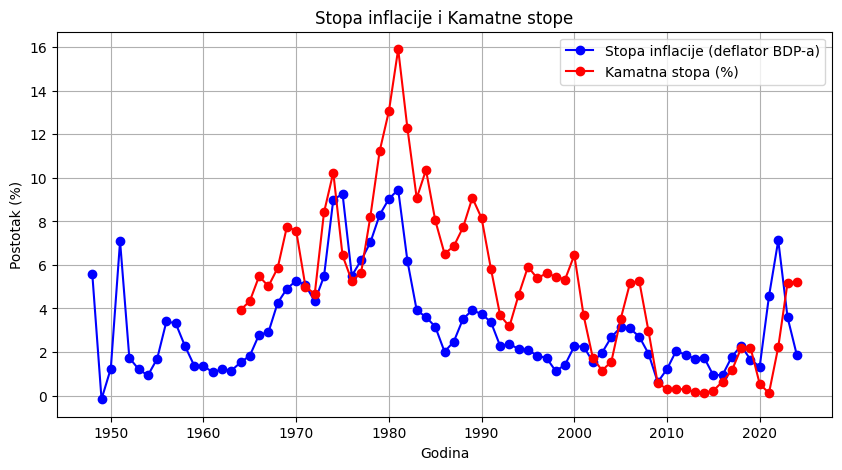

In [5]:

avg_nominal_gdp['Nominal_GDP'] = pd.to_numeric(avg_nominal_gdp.get('GDP', avg_nominal_gdp.get('Nominal_GDP')), errors='coerce')
avg_real_gdp['Real_GDP'] = pd.to_numeric(avg_real_gdp.get('GDPC1', avg_real_gdp.get('Real_GDP')), errors='coerce')
avg_interest_rate['Interest_Rate'] = pd.to_numeric(avg_interest_rate.get('IR3TIB01USM156N', avg_interest_rate.get('Interest_Rate')), errors='coerce')

# Spoji serije po godini
df = pd.merge(avg_nominal_gdp[['Year','Nominal_GDP']], avg_real_gdp[['Year','Real_GDP']], on='Year', how='inner')
df = pd.merge(df, avg_interest_rate[['Year','Interest_Rate']], on='Year', how='left')

# Izračunaj deflator i godišnju stopu inflacije (u %)
df = df.sort_values('Year').reset_index(drop=True)
df['GDP_Deflator'] = df['Nominal_GDP'] / df['Real_GDP']
df['Inflation'] = df['GDP_Deflator'].pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Inflation'], label='Stopa inflacije (deflator BDP-a)', color='blue', marker='o')
plt.plot(df['Year'], df['Interest_Rate'], label='Kamatna stopa (%)', color='red', marker='o')
plt.title('Stopa inflacije i Kamatne stope')
plt.xlabel('Godina')
plt.ylabel('Postotak (%)')
plt.legend()
plt.grid()
plt.show()

## Zadatak 2 -- Knjiga naloga i njeno uzorkovanje

Implementirajte tri različite metode uzorkovanja knjige naloga: (1) vremensko uzorkovanje, (2) uzorkovanje po količini, (3) uzorkovanje po prometu, te konačno usporediti rezultate dobivene svakom metodom.


U mapi data/zadatak_2 nalaze se dvije .csv datoteke koje opisuju knjigu naloga dionice Applea za jedan dan trgovanja:

1. Datoteka s porukama sadrži 5 stupaca, tj. informacije o vremenskim oznakama (u sekundama od ponoći), tipu događaja (npr. novi nalog, izvršenje, otkazivanje), veličini naloga, cijeni i smjeru (1 = kupnja, -1 = prodaja).
2. Datoteka knjige naloga sadrži 4 stupca s informacijama o vremenskoj oznaci, najboljoj bid i ask cijeni te količini dostupnoj za kupnju i prodaju u tom trenutku. Cijena je prikazana kao cijeli broj (pomnožena s 10000).

U datoteci s porukama (messages.csv) od interesa su događaji tipa 4 i 5, tj. izvršenje kupnje i prodaje. Također, preporučujemo pročitati dokument LOBSTER_SampleFiles_ReadMe.txt, koji se nalazi u mapi data/zadatak_2.

Zadaci za specifične načine uzorkovanja su u nastavku, a za detalje o sve tri metode proučite 2. poglavlje knjige de Prado, M. L., Advances in Financial Machine Learning. New Jersey: Wiley, 2018. 



In [6]:
import pandas as pd
names_messages = ['time', 'type', 'order id', 'size', 'price', 'direction']
names_order_book = ['time', 'best ask', 'best ask volume', 'best bid', 'best bid volume', 'second best ask']
messages_df = pd.read_csv('data/zadatak_2/messages.csv', names=names_messages)
order_book_df = pd.read_csv('data/zadatak_2/order_book.csv', names=names_order_book)

messages_df.head(), order_book_df.head()

(           time  type  order id  size    price  direction
 0  34200.004241     1  16113575    18  5853300          1
 1  34200.025552     1  16120456    18  5859100         -1
 2  34200.201743     3  16120456    18  5859100         -1
 3  34200.201781     3  16120480    18  5859200         -1
 4  34200.205573     1  16167159    18  5853600          1,
       time  best ask  best ask volume  best bid  best bid volume  \
 0  5859400       200          5853300        18              NaN   
 1  5859100        18          5853300        18              NaN   
 2  5859200        18          5853300        18              NaN   
 3  5859300       100          5853300        18              NaN   
 4  5859300       100          5853600        18              NaN   
 
    second best ask  
 0              NaN  
 1              NaN  
 2              NaN  
 3              NaN  
 4              NaN  )

Prva metoda uzorkovanja koju je potrebno razviti je vremensko uzorkovanje. Ova metoda grupira naloge u definirane vremenske intervale (standardno 1 minuta) i sažima ih pomoću OHLCV podataka:

- Prva cijena (Open),
- Najviša cijena (High),
- Najniža cijena (Low),
- Zadnja cijena (Close),
- Ukupan volumen (Volume).

Napišite funkciju koja prima podatke, grupira ih po vremenskim intervalima i generira OHLCV podatke za svaki interval.
Izlaz funckije neka bude `pd.DataFrame`, s vremenskim oznakama kao indeksom.


In [7]:
def time_based_sampling(data, interval='1min'):
    executions = data[data['type'].isin([4, 5])].copy()
    executions['price'] = executions['price'] / 10000.0

    executions['datetime'] = pd.to_datetime(executions['time'], unit='s')
    executions = executions.set_index('datetime')

    ohlcv = pd.DataFrame()
    ohlcv['Open'] = executions['price'].resample(interval).first()
    ohlcv['High'] = executions['price'].resample(interval).max()
    ohlcv['Low'] = executions['price'].resample(interval).min()
    ohlcv['Close'] = executions['price'].resample(interval).last()
    ohlcv['Volume'] = executions['size'].resample(interval).sum()
    
    return ohlcv.dropna()

Druga metoda uzorkovanja koju je potrebno razviti je Uzorkovanje po količini. Ova metoda grupira naloge u intervale prema količini, standardno po 1000 jedinica volumena, i za svaki interval generira OHLC podatke. Vremenski razmak između dviju točaka u ovoj metodi ovisi o vremenu potrebnom za trgovanje 1000 jedinica volumena.

Napišite funkciju koja prima podatke, grupira ih po volumenu i generira OHLC podatke za svaki interval količine.
Izlaz funckije neka bude `pd.DataFrame`, s vremenskim oznakama kao indeksom.




In [8]:
def volume_based_sampling(data, volume_interval=1000):
    # Implementacija uzorkovanja količine
    # Grupirajte naloge po zadanim intervalima količine
    executions = data[data['type'].isin([4, 5])].copy()
    executions['price'] = executions['price'] / 10000.0
    executions['datetime'] = pd.to_datetime(executions['time'], unit='s')
    executions = executions.sort_values('datetime').reset_index(drop=True)
    executions['cumulative_volume'] = executions['size'].cumsum()
    executions['volume_bin'] = (executions['cumulative_volume'] // volume_interval).astype(int)

    ohlc = executions.groupby('volume_bin').agg(
        Open=('price', 'first'),
        High=('price', 'max'),
        Low=('price', 'min'),
        Close=('price', 'last'),
        Volume=('size', 'sum'),
        datetime=('datetime', 'first')
    ).reset_index(drop=True)
    ohlc.set_index('datetime', inplace=True)
    return ohlc

Treća metoda uzorkovanja je uzorkovanje po prometu, koje koristi intervale definirane prema ukupnoj vrijednosti trgovanja (cijena × volumen, standardno 100000 USD). Cilj je grupirati naloge prema ukupnom prometu i sažeti ih u OHLCV formatu. Vremenski razmak između dviju točaka u ovoj metodi ovisi o vremenu potrebnom za trgovanje 100000 USD. 

Implementirajte funkciju koja prima podatke, grupira ih prema intervalima prometa i generira OHLCV podatke za svaki interval. Izlaz funckije neka bude `pd.DataFrame`, s vremenskim oznakama kao indeksom.


In [9]:
def dollar_volume_sampling(data, dollar_interval=100000):
    # Implementacija uzorkovanja prometa
    # Grupirajte naloge prema intervalima prometa
    executions = data[data['type'].isin([4, 5])].copy()
    executions['price'] = executions['price'] / 10000.0
    executions['datetime'] = pd.to_datetime(executions['time'], unit='s')
    executions = executions.sort_values('datetime').reset_index(drop=True)
    executions['dollar_volume'] = executions['price'] * executions['size']
    executions['cumulative_dollar_volume'] = executions['dollar_volume'].cumsum()
    executions['dollar_volume_bin'] = (executions['cumulative_dollar_volume'] // dollar_interval).astype(int)

    ohlc = executions.groupby('dollar_volume_bin').agg(
        Open=('price', 'first'),
        High=('price', 'max'),
        Low=('price', 'min'),
        Close=('price', 'last'),
        Volume=('size', 'sum'),
        datetime=('datetime', 'first')
    ).reset_index(drop=True)
    ohlc.set_index('datetime', inplace=True)
    return ohlc

Nakon što ste implementirali sve tri metode uzorkovanja, vizualizirajte dobivene podatke kako biste ih usporedili:
1. Prikažite OHLC podatke za svaku metodu na različitom grafu (primjetitie: `open`, `high`, `low`, `close` su četiri različite linije na grafu)
2. Na odvojenom grafu prikažite `close` vrijednosti dobivene koristeći sve tri metode. 

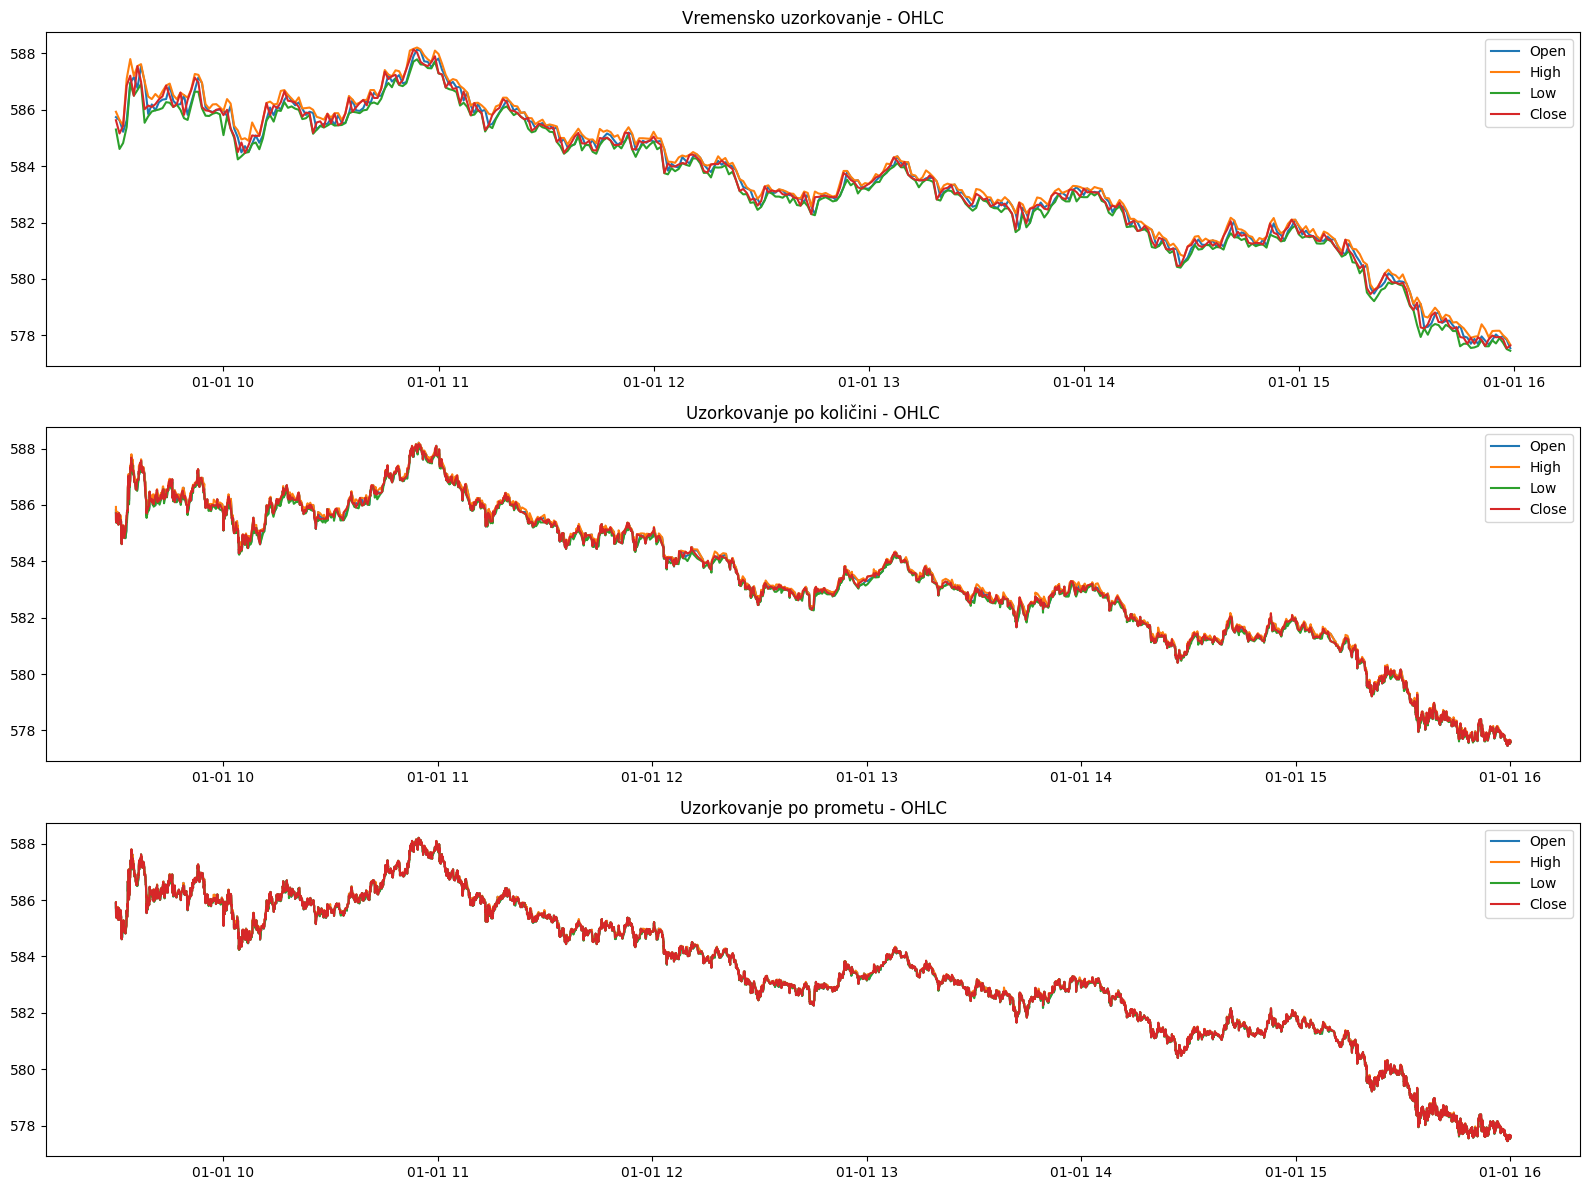

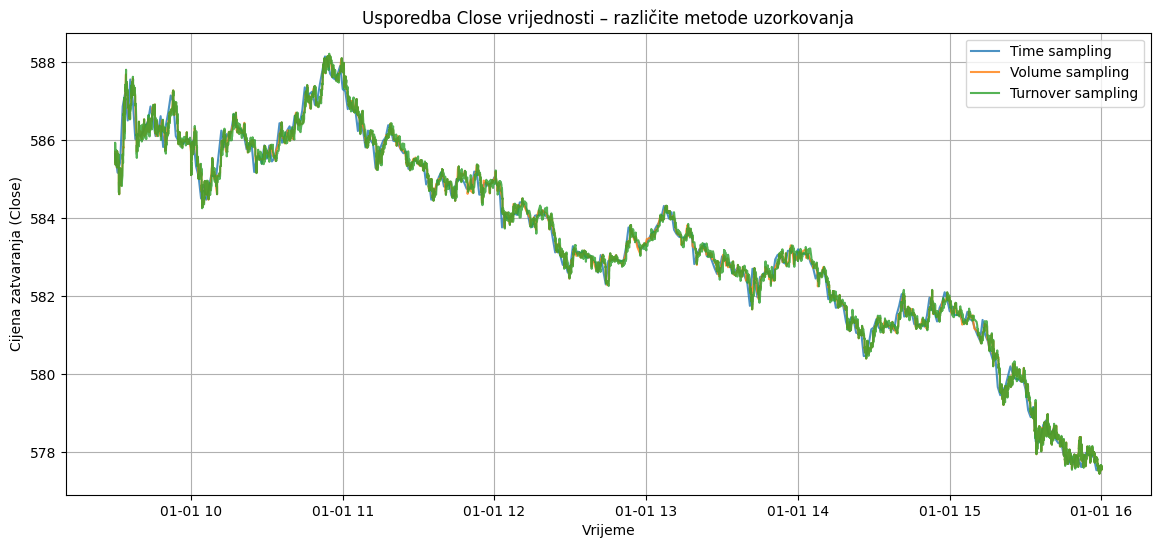

In [10]:
ohlcv_time = time_based_sampling(messages_df)
ohlcv_volume = volume_based_sampling(messages_df, volume_interval=1000)
ohlcv_dollar = dollar_volume_sampling(messages_df, dollar_interval=100000)
plt.figure(figsize=(16, 12))


plt.subplot(3, 1, 1)
plt.plot(ohlcv_time.index, ohlcv_time['Open'], label='Open')
plt.plot(ohlcv_time.index, ohlcv_time['High'], label='High')
plt.plot(ohlcv_time.index, ohlcv_time['Low'], label='Low')
plt.plot(ohlcv_time.index, ohlcv_time['Close'], label='Close')
plt.title('Vremensko uzorkovanje - OHLC')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(ohlcv_volume.index, ohlcv_volume['Open'], label='Open')
plt.plot(ohlcv_volume.index, ohlcv_volume['High'], label='High')
plt.plot(ohlcv_volume.index, ohlcv_volume['Low'], label='Low')
plt.plot(ohlcv_volume.index, ohlcv_volume['Close'], label='Close')
plt.title('Uzorkovanje po količini - OHLC')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(ohlcv_dollar.index, ohlcv_dollar['Open'], label='Open')
plt.plot(ohlcv_dollar.index, ohlcv_dollar['High'], label='High')
plt.plot(ohlcv_dollar.index, ohlcv_dollar['Low'], label='Low')
plt.plot(ohlcv_dollar.index, ohlcv_dollar['Close'], label='Close')
plt.title('Uzorkovanje po prometu - OHLC')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(ohlcv_time.index, ohlcv_time['Close'], label='Time sampling', alpha=0.8)
plt.plot(ohlcv_volume.index, ohlcv_volume['Close'], label='Volume sampling', alpha=0.8)
plt.plot(ohlcv_dollar.index, ohlcv_dollar['Close'], label='Turnover sampling', alpha=0.8)
plt.title('Usporedba Close vrijednosti – različite metode uzorkovanja')
plt.xlabel('Vrijeme')
plt.ylabel('Cijena zatvaranja (Close)')
plt.legend()
plt.grid(True)
plt.show()

Za `close` vrijednosti dobivene koristeći sve tri metode, izračunajte prosječno vrijeme između vremenskih točaka i usporedite dobivene rezultate.

In [11]:
time_diffs = ohlcv_time.index.to_series().diff().dropna()
average_time_diff = time_diffs.mean()
volume_diffs = ohlcv_volume.index.to_series().diff().dropna()
average_volume_diff = volume_diffs.mean()

dollar_diffs = ohlcv_dollar.index.to_series().diff().dropna()
average_dollar_diff = dollar_diffs.mean()

print(f"Prosječno vrijeme između vremenskih točaka (Time-based): {average_time_diff}")
print(f"Prosječno vrijeme između volumenskih točaka (Volume-based): {average_volume_diff}")
print(f"Prosječno vrijeme između točaka prema prometu (Dollar-based): {average_dollar_diff}")

Prosječno vrijeme između vremenskih točaka (Time-based): 0 days 00:01:00
Prosječno vrijeme između volumenskih točaka (Volume-based): 0 days 00:00:08.303466644
Prosječno vrijeme između točaka prema prometu (Dollar-based): 0 days 00:00:01.646586313


## Zadatak 3 - Stilizirane činjenice logaritamskih povrata

Stilizirane činjenice, i to:
- autokorelacija logaritamskih povrata,
- autokorelacija apsolutnih logaritamskih povrata,
- teški repovi distribucije povrata,

 potrebno je ispitati na dvije različite frekvencije: minutoj i dnevnoj, te za dva različita financijska instrumenta: dionice Applea i futures ugovore na sirovu naftu (Crude Oil - CL).

Podaci se nalaze u mapi `zadatak_3`, i to:

- Minutni podaci o cijenama dionica Applea i futures ugovora na sirovu naftu su u pojedinačnim .csv datotekama za svaki dan, s vremenskim oznakama od 09:30 do 16:00.
- Dnevni podaci o cijena dionica Applea i futures ugovora na sirovu naftu nalaze se u odvojenim .csv datotekama.


Učitajte podatke i izračunajte logaritamske povrate za dnevne podatke.


In [12]:
apple_daily = pd.read_csv('data/zadatak_3/apple_daily_data.csv')
oil_futures_daily = pd.read_csv('data/zadatak_3/crude_oil_daily_data.csv')

def calculate_log_returns(data, price_column='Close'):
    data['Log_Return'] = np.log(data[price_column] / data[price_column].shift(1))
    return data.dropna()

apple_daily = calculate_log_returns(apple_daily)
oil_futures_daily = calculate_log_returns(oil_futures_daily)

c:\Users\Admin\Desktop\fer\diplomski\3. sem\Analitika financija\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Izračunajte i prikažite autokorelaciju logaritamskih povrata pomoću funkcije `acf` iz biblioteke `statsmodels`, uz 20 zakašnjelih vrijednosti (engl. lag). Je li očit izostanak autokorelacije u logaritamskim povratima u dnevnim podacima?


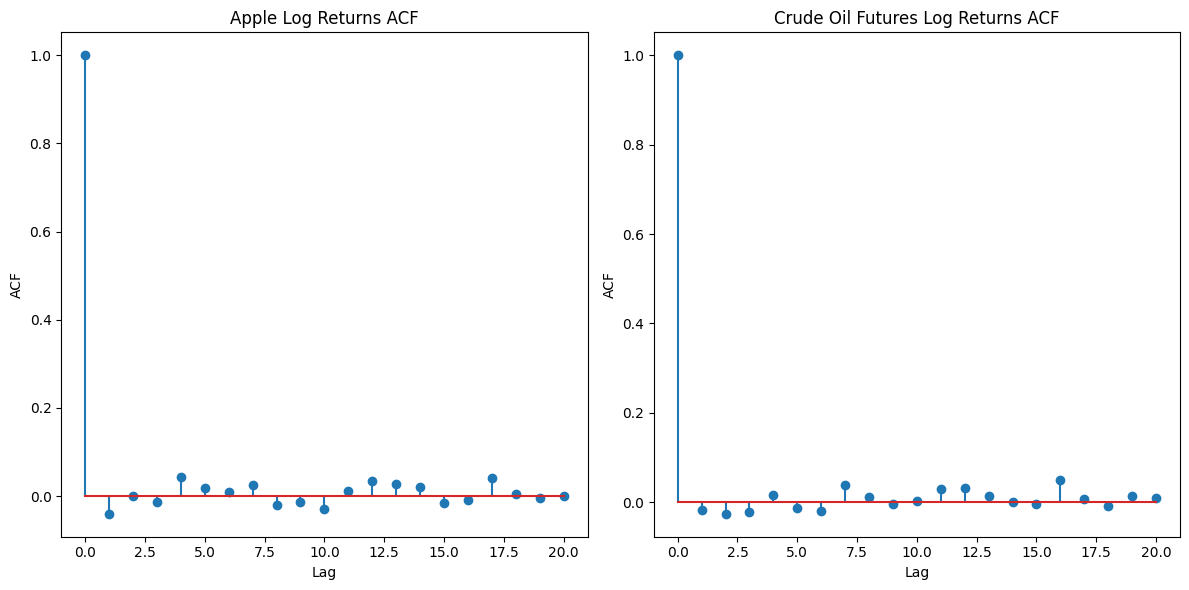

In [13]:
from statsmodels.tsa.stattools import acf
from matplotlib import pyplot as plt

apple_acf_values = acf(apple_daily['Log_Return'], nlags=20)
oil_acf_values = acf(oil_futures_daily['Log_Return'], nlags=20)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.stem(range(len(apple_acf_values)), apple_acf_values)
plt.title('Apple Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.subplot(1, 2, 2)
plt.stem(range(len(oil_acf_values)), oil_acf_values)
plt.title('Crude Oil Futures Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()

Izračunajte i prikažite autokorelaciju apsolutnih logaritamskih povrata pomoću funkcije `acf` iz biblioteke `statsmodels`, uz 20 zakašnjelih vrijednosti (engl. lag). Je li očito prisutna autokorelacija u apsolutnim logaritamskim povratima u dnevnim podacima?

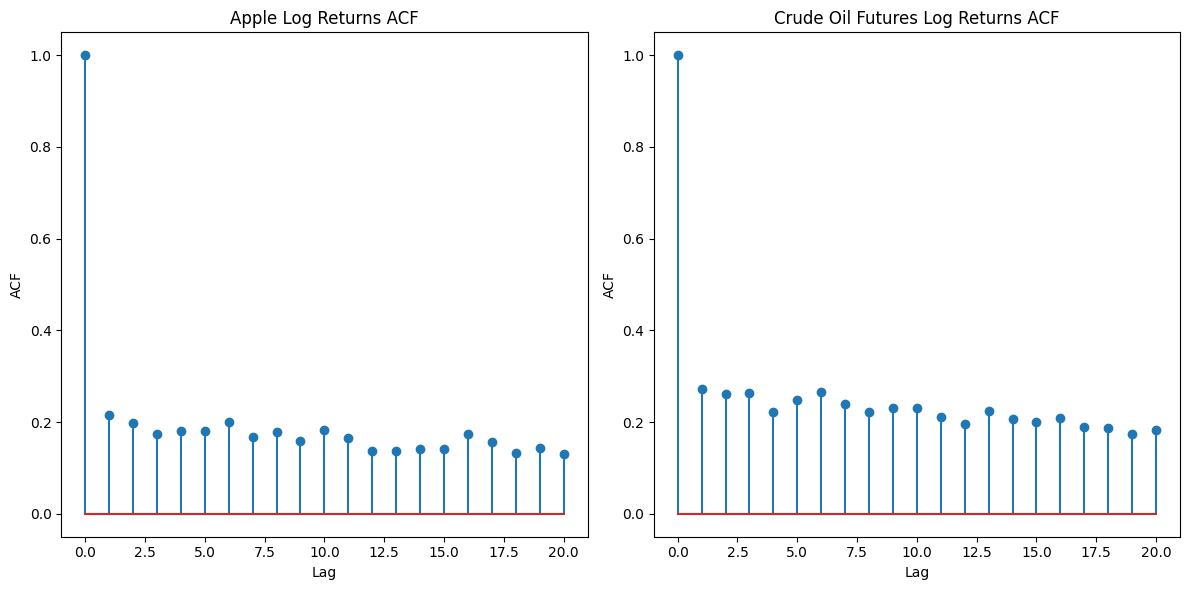

In [14]:
from statsmodels.tsa.stattools import acf
abs_apple_acf_values = acf(np.abs(apple_daily['Log_Return']), nlags=20)
abs_oil_acf_values = acf(np.abs(oil_futures_daily['Log_Return']), nlags=20)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.stem(range(len(abs_apple_acf_values)), abs_apple_acf_values)
plt.title('Apple Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.subplot(1, 2, 2)
plt.stem(range(len(abs_oil_acf_values)), abs_oil_acf_values)
plt.title('Crude Oil Futures Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()


Standardizirajte logaritamske povrate (izračunajte z-score za svaku vrijednost).

In [15]:
apple_daily['Z_Score'] = (apple_daily['Log_Return'] - apple_daily['Log_Return'].mean()) / apple_daily['Log_Return'].std()
oil_futures_daily['Z_Score'] = (oil_futures_daily['Log_Return'] - oil_futures_daily['Log_Return'].mean()) / oil_futures_daily['Log_Return'].std()
apple_daily.head(), oil_futures_daily.head()

(                        Date  Adj Close     Close      High       Low  \
 1  2000-01-04 00:00:00+00:00   0.772846  0.915179  0.987723  0.903460   
 2  2000-01-05 00:00:00+00:00   0.784155  0.928571  0.987165  0.919643   
 3  2000-01-06 00:00:00+00:00   0.716296  0.848214  0.955357  0.848214   
 4  2000-01-07 00:00:00+00:00   0.750226  0.888393  0.901786  0.852679   
 5  2000-01-10 00:00:00+00:00   0.737031  0.872768  0.912946  0.845982   
 
        Open     Volume  Log_Return   Z_Score  
 1  0.966518  512377600   -0.088077 -3.461492  
 2  0.926339  778321600    0.014527  0.532143  
 3  0.947545  767972800   -0.090514 -3.556326  
 4  0.861607  460734400    0.046281  1.768096  
 5  0.910714  505064000   -0.017744 -0.723950  ,
                         Date  Adj Close      Close       High        Low  \
 1  2000-08-24 00:00:00+00:00  31.629999  31.629999  32.240002  31.400000   
 2  2000-08-25 00:00:00+00:00  32.049999  32.049999  32.099998  31.320000   
 3  2000-08-28 00:00:00+00:00  32.

Na istom grafu prikažite, tj usporedite histogram standardiziranih povrata i histogram uzorkovane standardne normalne distribucije $\mathcal{N}(0, 1)$. 
Standardnu normalnu distribuciju možete uzorkovati koristeći `numpy` biblioteku, kao `np.random.normal(0, 1, 1000)`. 

U `matplotlibu` možete koristiti funkcije `plt.hist` za prikaz histograma, distribucije prikažite različitim bojama, dodajte oznake i legendu, stavite `alpha` parametar na 0.5, `bins` na 1000, a `density` na `True`. Za očitije razlike prikažite y os u logaritamskoj skali.

Jesu li ekstremne vrijednosti češće prisutne u standardiziranim povratima dionice Applea ili među vrijednostima standardne normalne distribucije?

Jesu li ekstremne vrijednosti češće prisutne u standardiziranim povratima futures ugovora na sirovu naftu ili među vrijednostima standardne normalne distribucije?


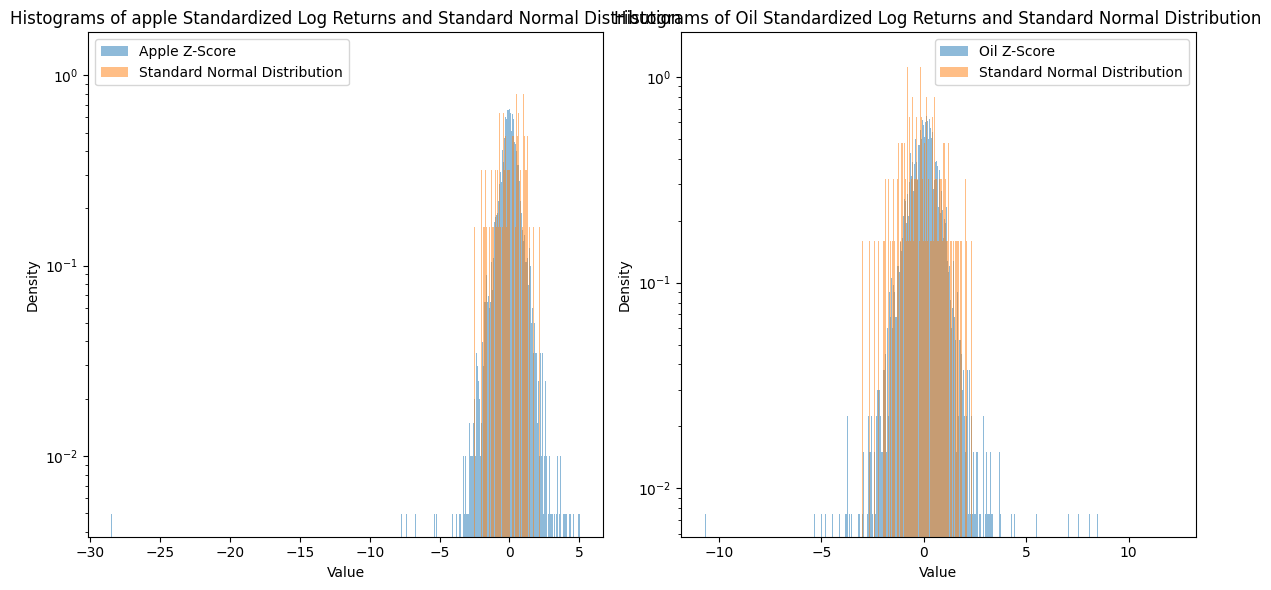

In [16]:
# na grafu prikažite histograme std povrata i standardne normalne distribucije
standardna_dist = np.random.normal(0, 1, 1000)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(apple_daily['Z_Score'], bins=1000, alpha=0.5, density=True, label='Apple Z-Score')
plt.hist(standardna_dist, bins=1000, alpha=0.5, density=True, label='Standard Normal Distribution')

plt.title('Histograms of apple Standardized Log Returns and Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)

plt.hist(oil_futures_daily['Z_Score'], bins=1000, alpha=0.5, density=True, label='Oil Z-Score')
plt.hist(standardna_dist, bins=1000, alpha=0.5, density=True, label='Standard Normal Distribution')

plt.title('Histograms of Oil Standardized Log Returns and Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

Ponovite postupak za minutne podatke.

In [17]:
import os

def load_minute_data(path):
   all_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]
   df_list = []
   for file in all_files:
      daily_data = pd.read_csv(file)
      df_list.append(daily_data)

   return pd.concat(df_list, ignore_index=True).copy()

apple_minute = load_minute_data('data/zadatak_3/AAPL_1min_preprocessed')
oil_futures_minute = load_minute_data('data/zadatak_3/CL_1min_preprocessed')

#apple_minute.head(), oil_futures_minute.tail()
apple_minute = calculate_log_returns(apple_minute, price_column='close')
oil_futures_minute = calculate_log_returns(oil_futures_minute, price_column='close')
apple_minute.head(), oil_futures_minute.head()

(                  Unnamed: 0     open     high      low    close     volume  \
 1  2020-01-02 09:31:00-05:00  72.6431  72.6947  72.5458  72.6014   804188.0   
 2  2020-01-02 09:32:00-05:00  72.5915  72.6701  72.5178  72.6443   689044.0   
 3  2020-01-02 09:33:00-05:00  72.6456  72.9133  72.6431  72.8519  1181268.0   
 4  2020-01-02 09:34:00-05:00  72.8470  72.9443  72.7463  72.9305   780728.0   
 5  2020-01-02 09:35:00-05:00  72.9453  73.0706  72.9379  73.0310  1181684.0   
 
    Log_Return  
 1   -0.000760  
 2    0.000591  
 3    0.002854  
 4    0.001078  
 5    0.001377  ,
                   Unnamed: 0   open   high    low  close  volume  Log_Return
 1  2020-01-02 09:31:00-05:00  58.35  58.38  58.29  58.33  1240.0   -0.000514
 2  2020-01-02 09:32:00-05:00  58.32  58.36  58.31  58.35   820.0    0.000343
 3  2020-01-02 09:33:00-05:00  58.35  58.42  58.34  58.41   923.0    0.001028
 4  2020-01-02 09:34:00-05:00  58.41  58.44  58.27  58.27  2035.0   -0.002400
 5  2020-01-02 09:35:00-0

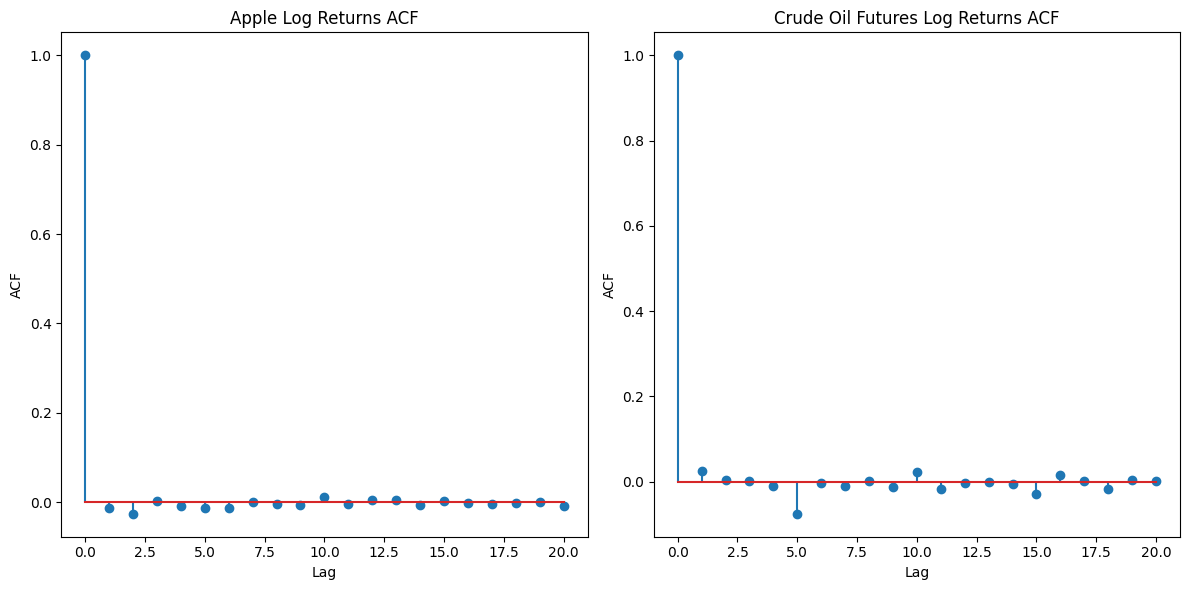

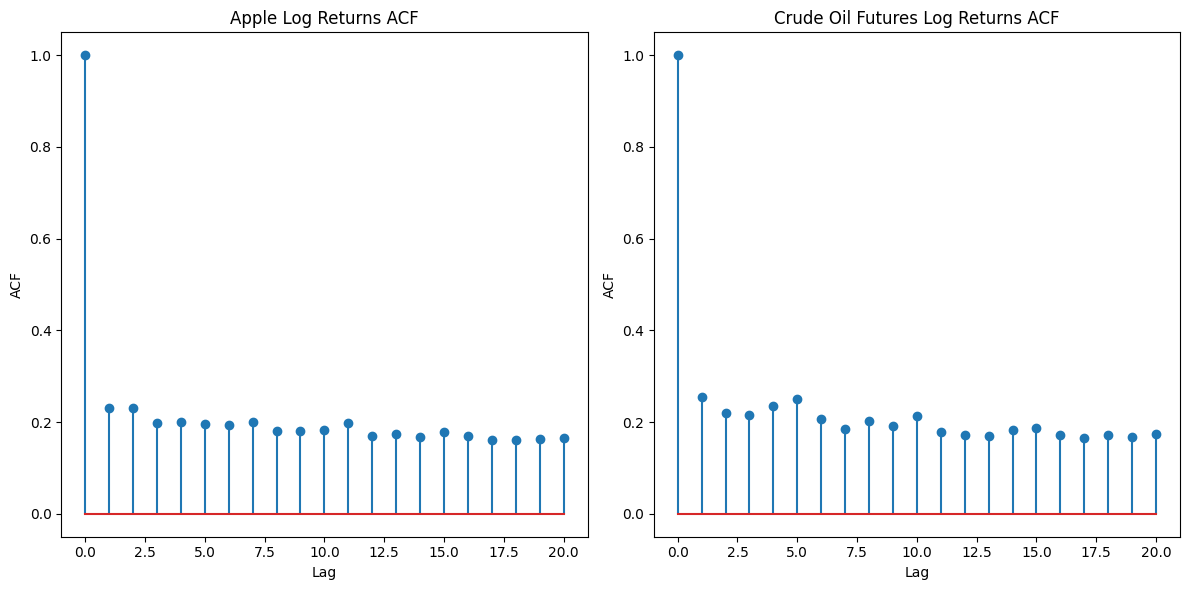

In [18]:
apple_acf_values2 = acf(apple_minute['Log_Return'], nlags=20)
oil_acf_values2 = acf(oil_futures_minute['Log_Return'], nlags=20)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.stem(range(len(apple_acf_values2)), apple_acf_values2)
plt.title('Apple Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.subplot(1, 2, 2)
plt.stem(range(len(oil_acf_values2)), oil_acf_values2)
plt.title('Crude Oil Futures Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()

from statsmodels.tsa.stattools import acf
abs_apple_acf_values2 = acf(np.abs(apple_minute['Log_Return']), nlags=20)
abs_oil_acf_values2 = acf(np.abs(oil_futures_minute['Log_Return']), nlags=20)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.stem(range(len(abs_apple_acf_values2)), abs_apple_acf_values2)
plt.title('Apple Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.subplot(1, 2, 2)
plt.stem(range(len(abs_oil_acf_values2)), abs_oil_acf_values2)
plt.title('Crude Oil Futures Log Returns ACF')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

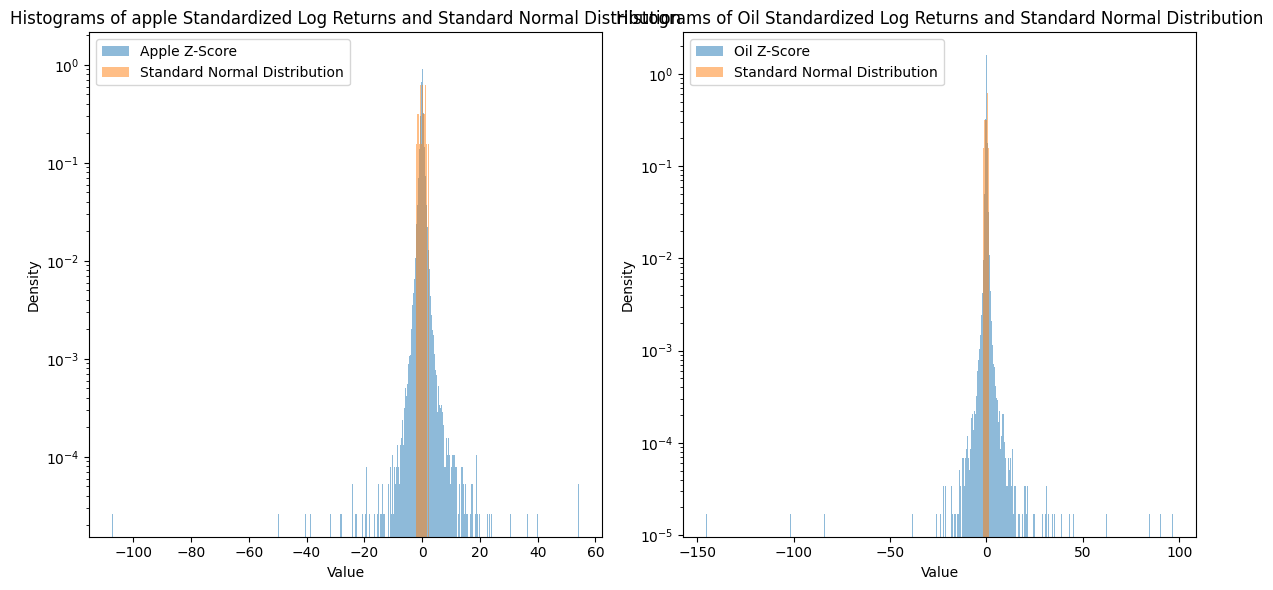

In [19]:
apple_minute['Z_Score'] = (apple_minute['Log_Return'] - apple_minute['Log_Return'].mean()) / apple_minute['Log_Return'].std()
oil_futures_minute['Z_Score'] = (oil_futures_minute['Log_Return'] - oil_futures_minute['Log_Return'].mean()) / oil_futures_minute['Log_Return'].std()
apple_minute.head(), oil_futures_minute.head()

standardna_dist = np.random.normal(0, 1, 1000)
plt.figure(figsize=(12, 6))

standardna_dist = np.random.normal(0, 1, 1000)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(apple_minute['Z_Score'], bins=1000, alpha=0.5, density=True, label='Apple Z-Score')
plt.hist(standardna_dist, bins=1000, alpha=0.5, density=True, label='Standard Normal Distribution')

plt.title('Histograms of apple Standardized Log Returns and Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)

plt.hist(oil_futures_minute['Z_Score'], bins=1000, alpha=0.5, density=True, label='Oil Z-Score')
plt.hist(standardna_dist, bins=1000, alpha=0.5, density=True, label='Standard Normal Distribution')

plt.title('Histograms of Oil Standardized Log Returns and Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

## Zadatak 4 - Modeli povrata

<b>ARMA model</b> kombinira autoregresivne (AR) i pokretne prosjeke (MA) komponente za modeliranje vremenskih serija koje su stacionarne. Općenito, ARMA(p,q) model može se zapisati kao:

$$
r_t = \phi_0 + \sum_{i=1}^{p} \phi_i r_{t-i} + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j} + \varepsilon_t
$$

gdje su:
- $ r_t $: logaritamski povrat u trenutku $ t $,
- $ \phi_0 $: konstanta modela,
- $ \phi_i $: koeficijenti autoregresivnog dijela modela (AR) reda $ p $,
- $ \theta_j $: koeficijenti dijela pokretnog prosjeka (MA) reda $ q $,
- $ \varepsilon_t $: bijeli šum, tj. slučajna varijabla s očekivanim iznosom nula i konstantnom varijancom $ \sigma^2 $.


Ipak, jednostavni ARMA modeli često nisu dovoljni za opisivanje promjenjive volatilnosti u financijskim vremenskim serijama, gdje su nestacionarnosti u volatilnosti česte. Kako bismo modelirali tu promjenjivu volatilnost, koristimo <b>GARCH(m, s) model</b>, koji omogućava opisivanje heteroskedastičnosti, tj. promjenjivosti varijance u vremenu.

Model povrata $r_t$ definiramo kao kombinaciju modela očekivanja $\mu$ i modela inovacije $a_t$:

$$
r_t = \mu + a_t, \quad a_t = \sigma_t \varepsilon_t.
$$

Inovacija $a_t$ prati GARCH(m, s) model, ako vrijedi: 

$$
\sigma_t^2 = \alpha_0 + \sum_{i=1}^{m} \alpha_i a_{t-i}^2 + \sum_{j=1}^{s} \beta_j \sigma_{t-j}^2
$$

gdje su:
- $ \alpha_0 $: konstanta modela koja postavlja osnovnu razinu varijance,
- $ \alpha_i $: koeficijenti koji opisuju utjecaj kvadrata prethodnih šokova $ a_{t-i}^2 $ na trenutnu varijancu (ARCH komponenta),
- $ \beta_j $: koeficijenti koji opisuju utjecaj prethodnih uvjetovanih varijanci $ \sigma_{t-j}^2 $ na trenutnu varijancu (GARCH komponenta).


Primijenite dva ARMA modela na dnevne logaritamske povrate dionica Apple-a, i to ARMA(5,5) i ARMA(1,1).

Procijenite parametre oba modela i usporedite modele na temelju metrike kvalitete prilagodbe, tj. $R^2$ vrijednosti. Ispišite parametre i metrike kvalitete prilagodbe.

Za prilagodbu modela koristite funkciju `ARMA` iz biblioteke `statsmodels`.

In [20]:
import pandas as pd
import numpy as np

apple_daily = pd.read_csv('data/zadatak_4/apple_daily_data.csv')
apple_daily = calculate_log_returns(apple_daily)

In [21]:
from statsmodels.tsa.arima.model import ARIMA #ARMA mi daje error
import warnings
warnings.filterwarnings("ignore")

arima_model11 = ARIMA(apple_daily["Log_Return"], order=(1, 0, 1)).fit()
print(arima_model11.summary())
arima_model55 = ARIMA(apple_daily["Log_Return"], order=(5, 0, 5)).fit()
print(arima_model55.summary())

def r_squared(model, data):
   fitted_values = model.fittedvalues
   ss_residual = np.sum((data - fitted_values) ** 2)
   ss_total = np.sum((data - np.mean(data)) ** 2)
   r2 = 1 - (ss_residual / ss_total)
   return r2
   
#usporedba modela temeljem R^2
print("R^2 za ARIMA(1,1):", r_squared(arima_model11, apple_daily["Log_Return"]))
print("R^2 za ARIMA(5,5):", r_squared(arima_model55, apple_daily["Log_Return"]))

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 5993
Model:                 ARIMA(1, 0, 1)   Log Likelihood               13445.525
Date:                Wed, 05 Nov 2025   AIC                         -26883.051
Time:                        09:31:11   BIC                         -26856.257
Sample:                             0   HQIC                        -26873.746
                               - 5993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.467      0.014       0.000       0.002
ar.L1          0.0932      0.183      0.509      0.610      -0.266       0.452
ma.L1         -0.1332      0.183     -0.729      0.4

Autokorelacijska funkcija (ACF) mjeri povezanost između trenutne vrijednosti vremenskog niza (logaritamskih povrata) i njegovih prošlih vrijednosti, definirana za različita kašnjenja (lagove). ACF se koristi za određivanje reda pokretnog prosjeka $ q $ komponente u ARMA modelu, jer se u MA modelima značajna autokorelacija pojavljuje za red $ q $, dok vrijednosti nakon toga opadaju prema nuli.

Parcijalna autokorelacijska funkcija (PACF) mjeri specifičnu povezanost trenutne vrijednosti vremenskog niza s određenim kašnjenjem, uklanjajući utjecaj međupovezanih kašnjenja. PACF stacionarnog vremenskog niza jest funkcija njegove autokorelacijske funkcije (ACF) i koristan je alat za određivanje reda $ p $ autoregresivnog (AR) modela. U AR modelu red $ p $ određen je brojem značajnih kašnjenja u PACF-u, nakon čega PACF opada prema nuli.

Jednostavan, ali učinkovit način za uvođenje PACF-a je razmatranje sljedećih AR modela uzastopnih redova:

$$
r_t = \phi_{0,1} + \phi_{1,1} r_{t-1} + e_{1t},
$$

$$
r_t = \phi_{0,2} + \phi_{1,2} r_{t-1} + \phi_{2,2} r_{t-2} + e_{2t},
$$

$$
r_t = \phi_{0,3} + \phi_{1,3} r_{t-1} + \phi_{2,3} r_{t-2} + \phi_{3,3} r_{t-3} + e_{3t},
$$

$$
r_t = \phi_{0,4} + \phi_{1,4} r_{t-1} + \phi_{2,4} r_{t-2} + \phi_{3,4} r_{t-3} + \phi_{4,4} r_{t-4} + e_{4t},
$$

$$
\vdots
$$

gdje su $ \phi_{0,j} $, $ \phi_{i,j} $, i $ \{ e_{jt} \} $ redom konstanta, koeficijent $ r_{t-i} $, i pogreška u AR($ j $) modelu. Više detalja o PACF-u možete pronaći u knjzi Ruey S. Tsay, Analysis of Financial Time Series (2005), potpoglavlje  2.4.

Prikažite ACF i PACF za dnevne podatke povrata dionica Applea koristeći `plot_acf` i `plot_pacf` iz biblioteke `statsmodels`. Postavite parametar `lags` na 20 kako biste prikazali prvih 20 kašnjenja, te parametar `zero` na `False` kako biste izostavili autokorelaciju nultog reda.

Na temelju prikaza ACF i PACF grafova, odaberite prikladne parametre za ARMA model, definirajući redove autoregresivne ($ p $) i pokretne prosječne ($ q $) komponente.

Prilagodite ARMA model na povrate dionica Appleas tako odabranim $ p $ i $ q $. Ispišite i usporedite metriku kvalitete prilagodbe $ R^2 $ s modelima iz prethodnog zadatka: ARMA(5,5) i ARMA(1,1).


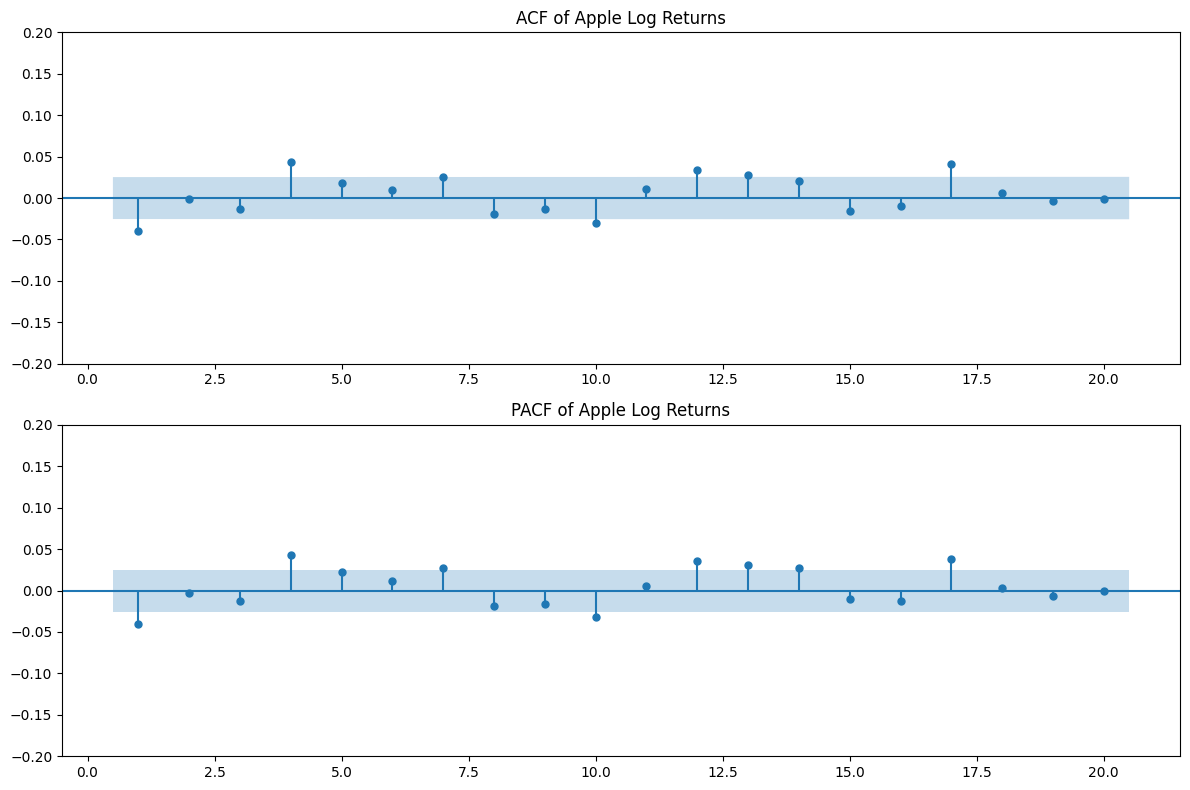

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 5993
Model:                 ARIMA(4, 0, 4)   Log Likelihood               13458.697
Date:                Wed, 05 Nov 2025   AIC                         -26897.394
Time:                        09:31:35   BIC                         -26830.411
Sample:                             0   HQIC                        -26874.132
                               - 5993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      2.291      0.022       0.000       0.002
ar.L1          0.1932      0.141      1.369      0.171      -0.083       0.470
ar.L2          0.5395      0.142      3.793      0.0

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(apple_daily["Log_Return"], lags=20, zero=False, ax=ax[0])
ax[0].set_title('ACF of Apple Log Returns')
ax[0].set_ylim(-0.2, 0.2)
plot_pacf(apple_daily["Log_Return"], lags=20, zero=False, ax=ax[1])
ax[1].set_title('PACF of Apple Log Returns')
ax[1].set_ylim(-0.2, 0.2)
plt.tight_layout()
plt.show()

p = 4
q = 4
arima_model_withpq = ARIMA(apple_daily["Log_Return"], order=(p, 0, q)).fit()
print(arima_model_withpq.summary())
print("R^2 za ARIMA({},0,{}): {}".format(p, q, r_squared(arima_model_withpq, apple_daily["Log_Return"])))

Procijenite GARCH(1,1) model za dnevne logaritamske povrate futures ugovora na sirovu naftu. 

Ako se volatilnost može modelirati GARCH(1,1) modelom, tada bi serija $\tilde{a_t}$ trebala biti nekorelirana, odnosno trebala bi se ponašati kao bijeli šum. Ipak, ako primijetimo značajne autokorelacije u $\tilde{a_t}$, to može sugerirati da GARCH(1,1) model nije u potpunosti uspio opisati obrasce u volatilnosti. 

Standardizirani reziduali $ \tilde{a}_t $ predstavljaju normaliziranu verziju inovacija u modelu. Definirani su kao:

$$
\tilde{a}_t = \frac{a_t}{\sigma_t},
$$

gdje je $ a_t $ stvarna vrijednost inovacije, a $ \sigma_t $ procijenjena uvjetovana standardna devijacija. Ako su standardizirani reziduali modelirani uspješno, oni bi trebali imati očekivanu srednju vrijednost od nula i standardnu devijaciju od jedan, te biti serijski nekorelirani.

Vizualizirajte autokorelaciju i standardizirane reziduale od $\tilde{a}_t$ za oba modela. 

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3.2879747916676386e+20
Iteration:      2,   Func. Count:     19,   Neg. LLF: 126583112630896.28
Iteration:      3,   Func. Count:     29,   Neg. LLF: -13943.907034945227
Optimization terminated successfully    (Exit mode 0)
            Current function value: -13943.907040097147
            Iterations: 7
            Function evaluations: 29
            Gradient evaluations: 3
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13943.9
Distribution:                  Normal   AIC:                          -27879.8
Method:            Maximum Likelihood   BIC:                          -27853.1
                                        No. Observations:                 5817
Date:         

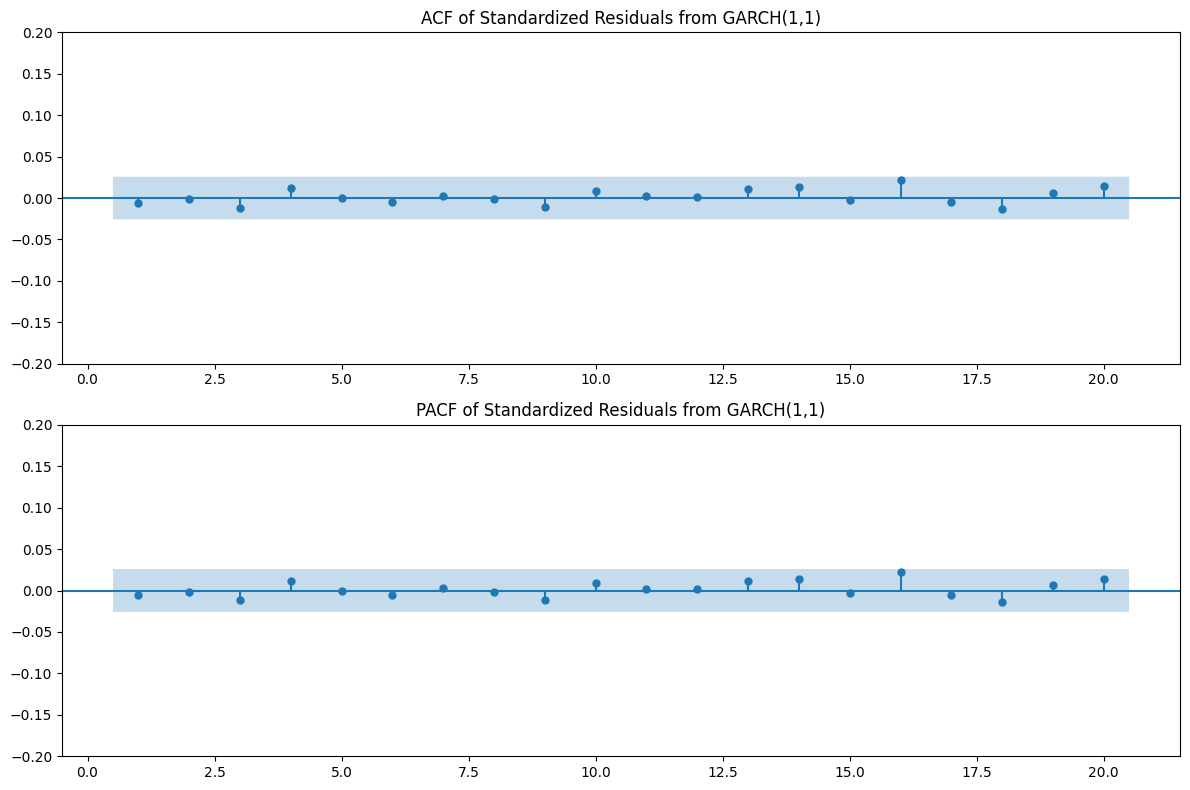

In [23]:
oil_futures_daily = pd.read_csv('data/zadatak_4/crude_oil_daily_data.csv')
oil_futures_daily = calculate_log_returns(oil_futures_daily)

from arch import arch_model
garch_model = arch_model(oil_futures_daily["Log_Return"], vol="Garch", p=1, q=1).fit()
print(garch_model.summary())

standardized_residuals = garch_model.resid / garch_model.conditional_volatility
print(pd.Series(standardized_residuals).describe())
# vizualizaija autokorelacije
fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(standardized_residuals, lags=20, zero=False, ax=ax[0])
ax[0].set_title('ACF of Standardized Residuals from GARCH(1,1)')
ax[0].set_ylim(-0.2, 0.2)
plot_pacf(standardized_residuals, lags=20, zero=False, ax=ax[1])
ax[1].set_title('PACF of Standardized Residuals from GARCH(1,1)')
ax[1].set_ylim(-0.2, 0.2)
plt.tight_layout()
plt.show()

Iskoristite prethodno prilagođen (vaš) ARMA model kao model sredine $\mu_t$ u GARCH(1,1) modelu za logaritamske povrate dionica Applea.

Usporedite tako dobiveni model (autokorelaciju i standardizirane reziduale) s modelima iz prethodnog zadatka ARMA(3,3), ARMA(1,1), GARCH(1,1).

Iteration:      1,   Func. Count:      6,   Neg. LLF: 16248159050.761497
Iteration:      2,   Func. Count:     21,   Neg. LLF: 963569496844.2733
Iteration:      3,   Func. Count:     36,   Neg. LLF: 3082400648082.6616
Iteration:      4,   Func. Count:     51,   Neg. LLF: 13651186123.745415
Optimization terminated successfully    (Exit mode 0)
            Current function value: -14568.221428423676
            Iterations: 4
            Function evaluations: 61
            Gradient evaluations: 4
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                14568.2
Distribution:                  Normal   AIC:                          -29128.4
Method:            Maximum Likelihood   BIC:                          -29101.6
                          

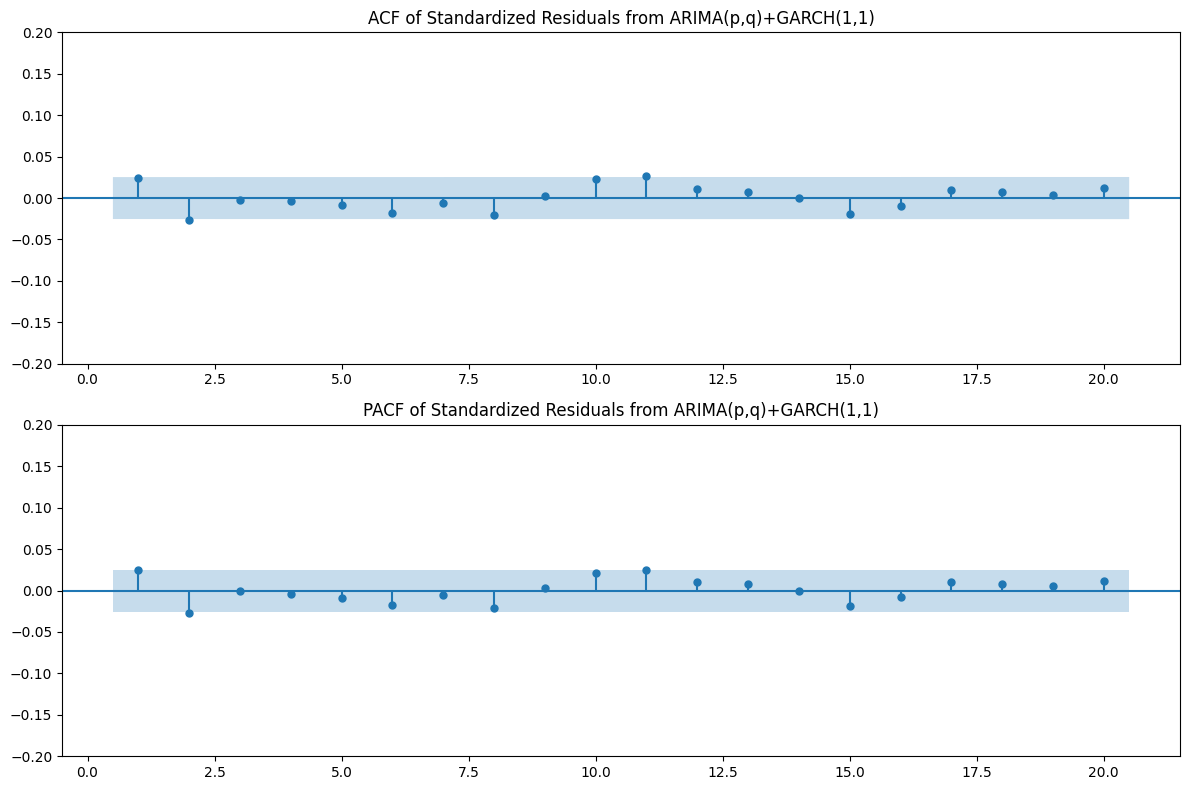

In [24]:
model_sredine = arima_model_withpq.resid
garch_model_oil = arch_model(model_sredine, vol="Garch", p=1, q=1).fit()
print(garch_model_oil.summary())
standardized_residuals_oil = garch_model_oil.resid / garch_model_oil.conditional_volatility
print("Standard residuals oil ARIMA(p,q)+GARCH(1,1):")
print(pd.Series(standardized_residuals_oil).describe())
# vizualizaija autokorelacije
fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(standardized_residuals_oil, lags=20, zero=False, ax=ax[0])
ax[0].set_title('ACF of Standardized Residuals from ARIMA(p,q)+GARCH(1,1)')
ax[0].set_ylim(-0.2, 0.2)
plot_pacf(standardized_residuals_oil, lags=20, zero=False, ax=ax[1])
ax[1].set_title('PACF of Standardized Residuals from ARIMA(p,q)+GARCH(1,1)')
ax[1].set_ylim(-0.2, 0.2)
plt.tight_layout()
plt.show()


Iskoristite **ARMA model kao model sredine** $\mu_t$ u **GARCH(1,1)** modelu za logaritamske povrate dionica Applea te ispitajte njegovu sposobnost generalizacije izvan uzorka procjene.

**Podijelite podatke na dva dijela** i to u omjeru 80% trening skup (in-sample) i 20% testni skup (out-of-sample):
- **trening skup (in-sample)** – koristi se za procjenu parametara modela,  
- **testni skup (out-of-sample)** – koristi se za provjeru prediktivne točnosti modela.

Izračunajte **inovacije (reziduale)** na testnom skupu pomoću procijenjenih parametara modela.

Imaju li očekivanu srednju vrijednost približno nula?  
Pokazuju li znakove autokorelacije (koristite ACF/PACF grafove)?

Innovation Mean: 0.000527142176689855
Innovation Std Dev: 0.020424295769638036
Standardized Innovations Description:
count    1199.000000
mean        0.020430
std         0.765592
min        -5.167722
25%        -0.347711
50%         0.020288
75%         0.442384
max         4.198147
dtype: float64


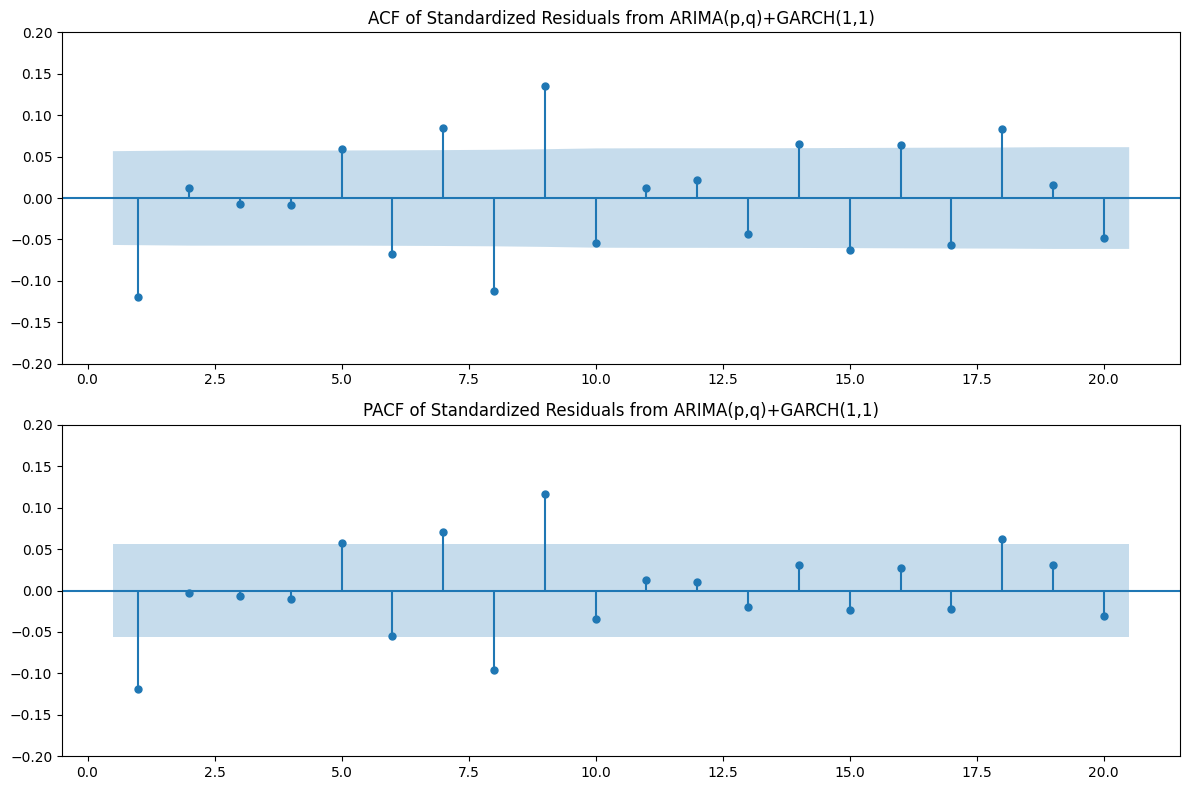

In [25]:
# treniranje i testiranje podataka 80 - 20%
training_data = apple_daily['Log_Return'][:int(0.8*len(apple_daily))]
test_data = apple_daily['Log_Return'][int(0.8*len(apple_daily)):]

arima_model_train = ARIMA(training_data, order=(p, 0, q)).fit()
predicted_mean = arima_model_train.predict(start=test_data.index[0], end=test_data.index[-1])
innovation_test = test_data - predicted_mean
innovation_mean = innovation_test.mean()
innovation_std = innovation_test.std()
print("Innovation Mean:", innovation_mean)
print("Innovation Std Dev:", innovation_std)

train_residuals = arima_model_train.resid.dropna()
garch_model_train = arch_model(train_residuals, mean="Zero", vol="Garch", p=1, q=1).fit(disp='off')
garch_forecasts = garch_model_train.forecast(horizon=len(test_data), reindex=False)
sigma_forecast = np.sqrt(garch_forecasts.variance.values[-1, :])
standardized_innovations = innovation_test / sigma_forecast
print("Standardized Innovations Description:")
print(pd.Series(standardized_innovations).describe())

fig, ax = plt.subplots(2, 1, figsize=(12,8))
plot_acf(standardized_innovations, lags=20, zero=False, ax=ax[0])
ax[0].set_title('ACF of Standardized Residuals from ARIMA(p,q)+GARCH(1,1)')
ax[0].set_ylim(-0.2, 0.2)
plot_pacf(standardized_innovations, lags=20, zero=False, ax=ax[1])
ax[1].set_title('PACF of Standardized Residuals from ARIMA(p,q)+GARCH(1,1)')
ax[1].set_ylim(-0.2, 0.2)
plt.tight_layout()
plt.show()

## Zadatak 5 - Faktorski modeli

Prvi model od interesa je jednofaktorski model povrata, koji koristi povrat tržišta kao faktor koji utječe na sve vrijednosnice: 

$$
r_{it} = \alpha_i + \beta_i r_{Mt} + \varepsilon_{it}
$$

gdje je $r_{it}$ povrat vrijednosnice $i$ iznad bezrizične kamatne stope (excess return), a $r_{Mt}$ povrat tržišta iznad bezrizične kamatne stope.



U mapi zadatak_5 nalaze se povijesne cijene dionica:

- LLY – Eli Lilly & Co
- JNJ – Johnson & Johnson
- ABBV – AbbVie Inc.
- UNH – UnitedHealth Group Inc
- ABT – Abbott Laboratories
- NVDA – Nvidia Corp
- MSFT – Microsoft Corp
- AAPL – Apple Inc.
- AVGO – Broadcom Inc.
- PLTR – Palantir Technologies Inc. Class A
- NEE – NextEra Energy Inc
- CEG – Constellation Energy Corp 
- SO – Southern Co 
- DUK – Duke Energy Corp 
- AEP – American Electric Power

Također, u mapi zadatak_5 nalazi se datoteka `sp500.csv`, koja sadrži povijesne cijene tržišnog indeksa S&P 500, te prinos tromjesečnog trezorskog zapisa (treasury bill) `tb3ms_data.csv`.

Učitajte podatke o povijesnim cijenama za sve dionice i tržišni indeks te izračunajte dnevne logaritamske povrate.


In [26]:
import os
import pandas as pd
import numpy as np

base = 'data/zadatak_5'
tickers = ["LLY","JNJ","ABBV","UNH","ABT","NVDA","MSFT","AAPL","AVGO","PLTR",
           "NEE","CEG","SO","DUK","AEP"]

returns_list = []
missing = []
for t in tickers:
    path = os.path.join(base, f"{t}_daily.csv")
    if not os.path.exists(path):
        missing.append(path)
        continue
    df = pd.read_csv(path)
    date_col = next((c for c in df.columns if c.lower() == 'date'), None)
    price_col = next((c for c in df.columns if c.lower() in ['close','adj close']), None)
    if date_col is None:
        date_col = df.columns[0]
    if price_col is None:
        price_col = df.columns[-1]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.set_index(date_col).sort_index()
    lr = np.log(df[price_col] / df[price_col].shift(1))
    lr.name = t
    returns_list.append(lr)

if missing:
    print("Missing files:", missing)

returns_df = pd.concat(returns_list, axis=1).dropna(how='all').sort_index()

sp_path = os.path.join(base, 'sp500_daily_data.csv')
if os.path.exists(sp_path):
    sp = pd.read_csv(sp_path)
    sp_date = next((c for c in sp.columns if c.lower() == 'date'), sp.columns[0])
    sp_price = next((c for c in sp.columns if c.lower() in ['close','adj close']), sp.columns[-1])
    sp[sp_date] = pd.to_datetime(sp[sp_date], errors='coerce')
    sp = sp.set_index(sp_date).sort_index()
    sp_ret = np.log(sp[sp_price] / sp[sp_price].shift(1))
    sp_ret.name = 'SP500'
    returns_df = pd.concat([returns_df, sp_ret], axis=1)
else:
    print("sp500.csv not found in", base)

print("Returns DataFrame shape:", returns_df.shape)
print("Columns:", returns_df.columns.tolist())
returns_df.head()

Returns DataFrame shape: (6492, 16)
Columns: ['LLY', 'JNJ', 'ABBV', 'UNH', 'ABT', 'NVDA', 'MSFT', 'AAPL', 'AVGO', 'PLTR', 'NEE', 'CEG', 'SO', 'DUK', 'AEP', 'SP500']


,LLY,JNJ,ABBV,UNH,ABT,NVDA,MSFT,AAPL,AVGO,PLTR,NEE,CEG,SO,DUK,AEP,SP500
Date,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,-0.031964,-0.037297,NaN,-0.012873,-0.028987,-0.027064,-0.034364,-0.088077,NaN,NaN,0.018019,NaN,0.010929,0.015424,0.011858,-0.039099
2000-01-05,0.012714,0.010501,NaN,-0.002358,-0.001840,-0.033476,0.010489,0.014527,NaN,NaN,0.032214,NaN,0.050342,0.040005,0.036648,0.001920
2000-01-06,0.028738,0.030856,NaN,0.035946,0.034392,-0.067479,-0.034072,-0.090514,NaN,NaN,0.000000,NaN,0.002581,0.026604,0.005666,0.000955
2000-01-07,0.071068,0.041659,NaN,0.110926,0.010620,0.016562,0.012984,0.046281,NaN,NaN,0.028411,NaN,0.017880,0.025914,0.013097,0.026730


Učitajte mjesečnu godišnju stopu tromjesečnog trezorskog zapisa iz datoteke `tb3ms_data.csv`

Konvertirajte godišnju stopu u dnevnu stopu koristeći pretpostavku od 252 dana trgovanja godišnje.

Prilagodite povrate pojedinih dionica te tržišnog indeksa oduzimanjem dnevne bezrizične stope za svaki dan (excess returns).

In [27]:
tb = pd.read_csv('data/zadatak_5/tb3ms_data.csv')
date_col = next((c for c in tb.columns if c.lower() in ['date','datum','observation_date']), None)
val_col = next((c for c in tb.columns if c.upper() in ['VALUE','TB3MS', 'VALUE.1V', 'TB3MS.1']), None)
tb[date_col] = pd.to_datetime(tb[date_col], errors='coerce')
tb = tb.set_index(date_col).sort_index()

tb[val_col] = pd.to_numeric(tb[val_col], errors='coerce')
tb['annual_rate'] = tb[val_col] / 100 
tb['daily_rf'] = (1 + tb['annual_rate']) ** (1/252) - 1

daily_rf_aligned = tb['daily_rf'].reindex(returns_df.index, method='ffill')
daily_rf_aligned = daily_rf_aligned.fillna(method='bfill')
excess_returns = returns_df.sub(daily_rf_aligned, axis=0)

print("tb3ms head:")
print(tb[['annual_rate','daily_rf']].head())
print("\nreturns_df columns:", returns_df.columns.tolist())
print("\nexcess_returns head:")
print(excess_returns.head())

tb3ms head:
                  annual_rate  daily_rf
observation_date                       
2000-01-01             0.0532  0.000206
2000-02-01             0.0555  0.000214
2000-03-01             0.0569  0.000220
2000-04-01             0.0566  0.000219
2000-05-01             0.0579  0.000223

returns_df columns: ['LLY', 'JNJ', 'ABBV', 'UNH', 'ABT', 'NVDA', 'MSFT', 'AAPL', 'AVGO', 'PLTR', 'NEE', 'CEG', 'SO', 'DUK', 'AEP', 'SP500']

excess_returns head:
                 LLY       JNJ  ABBV       UNH       ABT      NVDA      MSFT  \
Date                                                                           
2000-01-03       NaN       NaN   NaN       NaN       NaN       NaN       NaN   
2000-01-04 -0.032170 -0.037503   NaN -0.013079 -0.029193 -0.027269 -0.034570   
2000-01-05  0.012508  0.010295   NaN -0.002564 -0.002046 -0.033682  0.010283   
2000-01-06  0.028532  0.030650   NaN  0.035740  0.034187 -0.067685 -0.034278   
2000-01-07  0.070862  0.041453   NaN  0.110720  0.010414  0.01635

Primijenite regresiju za svaku dionicu koristeći povrate dionica kao zavisne varijable i povrate tržišnog indeksa kao nezavisnu varijablu.

Ispišite i vizualizirajte koeficijente $\alpha$ i $\beta$ za svaku dionicu.

           Alpha      Beta        R2
Ticker                              
PLTR    0.001358  1.958578  0.228360
NVDA    0.000816  1.661457  0.299742
AVGO    0.000696  1.359683  0.395483
CEG     0.001819  1.206642  0.199834
AAPL    0.000595  1.154994  0.315805
MSFT    0.000086  1.093715  0.498179
UNH     0.000410  0.797236  0.238374
ABBV    0.000230  0.699273  0.202371
LLY     0.000205  0.681683  0.224183
ABT     0.000146  0.623724  0.254323
NEE     0.000256  0.607474  0.240503
AEP     0.000035  0.574933  0.210229
DUK     0.000009  0.541386  0.193375
JNJ     0.000065  0.502700  0.258522
SO      0.000152  0.445366  0.177770


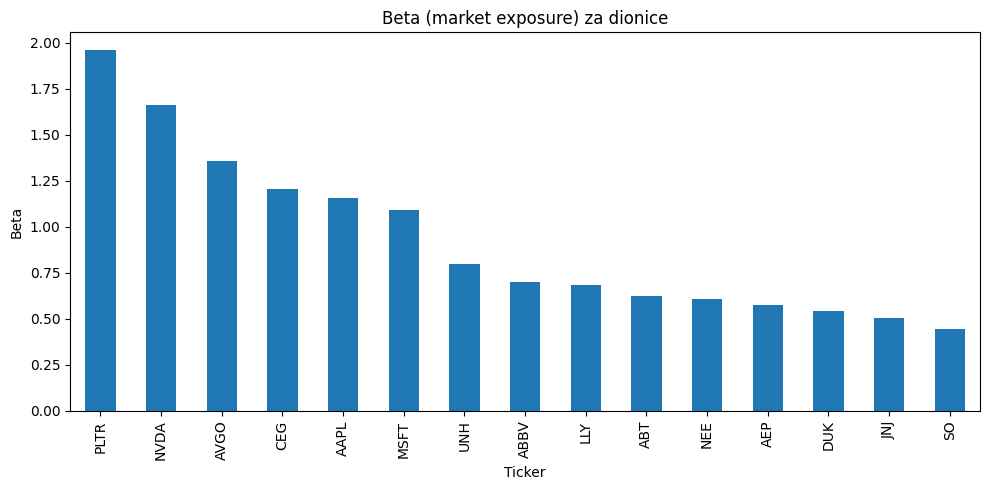

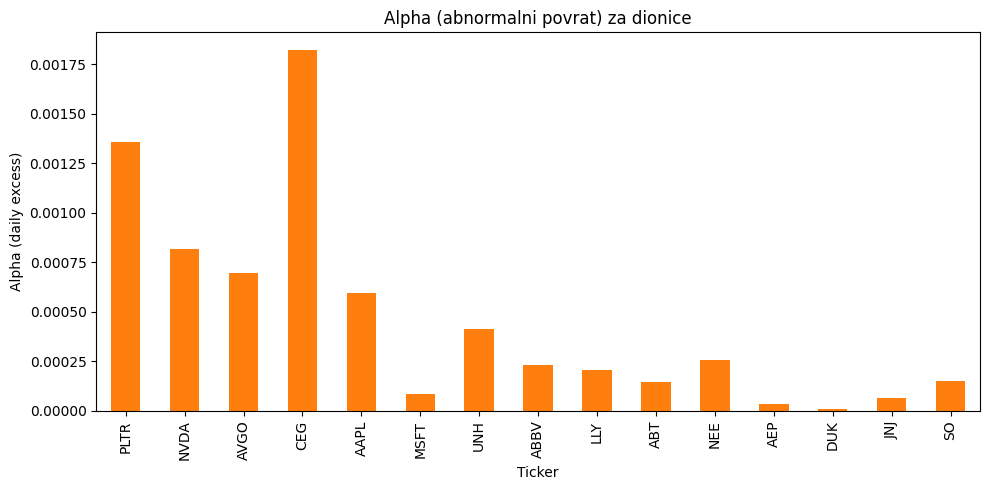

In [28]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
excess = None
for name in ('excess_returns', 'excess_returns_df'):
    val = globals().get(name)
    if val is not None:
        excess = val
        break

# pronađi kolonu tržišta
market_col = 'SP500' if 'SP500' in excess.columns else next((c for c in excess.columns if 'sp' in c.lower()), None)

tickers = [c for c in excess.columns if c != market_col]

results = []
for t in tickers:
    df = excess[[t, market_col]].dropna()
    if df.empty:
        results.append((t, np.nan, np.nan, np.nan))
        continue
    y = df[t]
    X = sm.add_constant(df[market_col])
    model = sm.OLS(y, X).fit()
    alpha = model.params.get('const', np.nan)
    beta = model.params.get(market_col, np.nan)
    results.append((t, alpha, beta, model.rsquared))

coef_df = pd.DataFrame(results, columns=['Ticker','Alpha','Beta','R2']).set_index('Ticker').sort_values('Beta', ascending=False)
print(coef_df)

# vizualizacija: beta i alpha barovi
plt.figure(figsize=(10,5))
coef_df['Beta'].plot(kind='bar', color='C0')
plt.title('Beta (market exposure) za dionice')
plt.ylabel('Beta')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
coef_df['Alpha'].plot(kind='bar', color='C1')
plt.title('Alpha (abnormalni povrat) za dionice')
plt.ylabel('Alpha (daily excess)')
plt.axhline(0, color='k', linewidth=0.7)
plt.tight_layout()
plt.show()

Drugi model od interesa je industrijski faktor model inspiriran BARRA pristupom za analizu dionica.

Na temelju industrijske klasifikacije, možemo definirati tri šire industrijske skupine za petnaest dionica:

- HEALTH CARE
    - LLY – Eli Lilly & Co
    - JNJ – Johnson & Johnson
    - ABBV – AbbVie Inc.
    - UNH – UnitedHealth Group Inc
    - ABT – Abbott Laboratories
- TECHNOLOGY
    - NVDA – Nvidia Corp
    - MSFT – Microsoft Corp
    - AAPL – Apple Inc.
    - AVGO – Broadcom Inc.
    - PLTR – Palantir Technologies Inc. Class A
- UTILITIES
    - NEE – NextEra Energy Inc
    - CEG – Constellation Energy Corp 
    - SO – Southern Co 
    - DUK – Duke Energy Corp 
    - AEP – American Electric Power

U skladu s BARRA pristupom, svaka od ovih skupina predstavlja zajednički faktor.

Industrijski faktor model možemo predstaviti kao:

$$
r_{it} = \beta_{i1} f_{1t} + \beta_{i2} f_{2t} + \varepsilon_{it}
$$  

gdje:

- $r_{it}$ predstavlja višak povrata dionice $i$ u trenutku $t$,
- $f_{1t}$ i $f_{2t}$ su povrati zajedničkih faktora za sektore Tech i Zdravstvo,
- $\beta_{i1}$ i $\beta_{i2}$ su indikatori koji pokazuju pripada li dionica $i$ sektoru 1 (Tech) ili sektoru 2 (Zdravstvo).

U tablici niže prikazana je binarna matrica beta vrijednosti za svaku dionicu i industrijsku skupinu:
<table> <tr> <th>Dionica</th> <th>TECHNOLOGY</th> <th>HEALTH CARE</th> <th>UTILITIES</th> </tr> <!-- Health Care --> <tr><td>LLY (Eli Lilly & Co)</td><td>0</td><td>1</td><td>0</td></tr> <tr><td>JNJ (Johnson & Johnson)</td><td>0</td><td>1</td><td>0</td></tr> <tr><td>ABBV (AbbVie Inc.)</td><td>0</td><td>1</td><td>0</td></tr> <tr><td>UNH (UnitedHealth Group Inc)</td><td>0</td><td>1</td><td>0</td></tr> <tr><td>ABT (Abbott Laboratories)</td><td>0</td><td>1</td><td>0</td></tr> <!-- Technology --> <tr><td>NVDA (Nvidia Corp)</td><td>1</td><td>0</td><td>0</td></tr> <tr><td>MSFT (Microsoft Corp)</td><td>1</td><td>0</td><td>0</td></tr> <tr><td>AAPL (Apple Inc.)</td><td>1</td><td>0</td><td>0</td></tr> <tr><td>AVGO (Broadcom Inc)</td><td>1</td><td>0</td><td>0</td></tr> <tr><td>PLTR (Palantir Technologies Inc. Class A)</td><td>1</td><td>0</td><td>0</td></tr> <!-- Utilities --> <tr><td>NEE (NextEra Energy Inc)</td><td>0</td><td>0</td><td>1</td></tr> <tr><td>CEG (Constellation Energy Corp)</td><td>0</td><td>0</td><td>1</td></tr> <tr><td>SO (Southern Co)</td><td>0</td><td>0</td><td>1</td></tr> <tr><td>DUK (Duke Energy Corp)</td><td>0</td><td>0</td><td>1</td></tr> <tr><td>AEP (American Electric Power)</td><td>0</td><td>0</td><td>1</td></tr> </table>

Vaš je zadatak prilagoditi industrijski faktor model inspiriran BARRA pristupom koji koristi sektorske faktore za analizu povrata dionica prateći postupak s predavanja (OLS i GLS). Detalje o postupku možete pronaći i u knjizi Ruey S. Tsay, Analysis of Financial Time Series (2005), potpoglavlje 9.3.


Formula **9.8** u preporučenoj literaturi za izračun **GLS-a** u **BARRA faktorskom modelu** sadrži **tipfeler** — u drugoj zagradi pojavljuje se **višak matrice β**, što je jasno iz dimenzija matrica i vektora. Ispravan općeniti oblik GLS procjene faktora glasi:

$$
F = (B' D^{-1} B)^{-1} (B' D^{-1} R_t), \quad t = 1, 2, 3, \ldots, T
$$

In [29]:
# <Vaš kod ovdje>

Ispišite srednju vrijednost i standardnu devijaciju GLS reziduala

In [30]:
# <Vaš kod ovdje>

Koristeći prilagođeni industrijski faktorski model, izračunajte korelacije povrata dionica unutar istih sektora (Tech i Zdravstvo) temeljene na modelu. 

Usporedite te korelacije s uzoračkim korelacijama (tj. korelacijama temeljenim na sirovim povratima bez prilagodbi za sektorske faktore).

In [31]:
# <Vaš kod ovdje>

U datoteci `zadatak_5/F-F_Research_Data_Factors_daily.csv` nalaze se dnevni podaci o Fama-French faktorima za analizu povrata dionica. Ovi faktori uključuju:

- Mkt-RF: tržišna premija rizika (razlika između tržišnog povrata i bezrizične stope),
- SMB: faktor veličine, poznat kao "Small Minus Big" (razlika povrata između malih i velikih tvrtki),
- HML: faktor vrijednosti, poznat kao "High Minus Low" (razlika povrata između dionica s visokim i niskim omjerom knjigovodstvene i tržišne vrijednosti),
- RF: bezrizična stopa, obično temeljena na stopi državnih obveznica.

Koristeći te podatke, prilagodite Fama-French model prema sljedećoj jednadžbi:

$$
r_{it} - r_f = \alpha + \beta_{\text{Mkt-RF}} \cdot \text{Mkt-RF} + \beta_{\text{SMB}} \cdot \text{SMB} + \beta_{\text{HML}} \cdot \text{HML} + \varepsilon_{it}
$$

gdje:
- $ r_{it} $ predstavlja dnevni povrat dionice $ i $,
- $ r_f $ je dnevna bezrizična stopa povrata,
- $ \alpha $ je konstanta modela,
- $ \beta_{\text{Mkt-RF}}, \beta_{\text{SMB}}, \beta_{\text{HML}} $ su koeficijenti povezani s odgovarajućim faktorima,
- $ \varepsilon_{it} $ su rezidualne vrijednosti modela.

U obzir možete uzeti dionice iz prethodnog zadatka.

In [32]:
# <Vaš kod ovdje>